# Exploratory Data Analysis of Short-Term Electricity Demand in NSW

## Objective

This exploratory data analysis examines half-hourly electricity demand in New South Wales. It investigates demand patterns across time, temperature conditions, public holidays and school-term periods. It also evaluates the existing 12-hour-prior and day-prior demand forecasts to identify patterns that may be useful for short-term forecasting.

## 1. Data, environment and preparation

In [3]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller, kpss
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", None)

In [4]:
file_path = r"C:\Users\sswap\OneDrive\Desktop\Swapnil\University\UNSW Masters\ZZSC9020 - Data Science Project\Data\nsw_features_added.csv"

demand = pd.read_csv(file_path)

print("Rows:", demand.shape[0])
print("Columns:", demand.shape[1])

display(demand.head())

Rows: 196513
Columns: 15


,DATETIME,TOTALDEMAND,REGIONID,LOCATION,TEMPERATURE,forecast_closest,forecast_12hr_prior,forecast_dayprior,year,month,day,radiation,is_public_holiday,is_school_term,day_of_week
0,2010-01-01 00:00:00,8038.00,NSW1,Bankstown,23.1,7999.11,7811.86,7822.38,2010,1,1,14.6,True,False,Friday
1,2010-01-01 00:30:00,7809.31,NSW1,Bankstown,22.9,7596.21,7612.63,7715.68,2010,1,1,14.6,True,False,Friday
2,2010-01-01 01:00:00,7483.69,NSW1,Bankstown,22.6,7380.70,7339.64,7482.56,2010,1,1,14.6,True,False,Friday
3,2010-01-01 01:30:00,7117.23,NSW1,Bankstown,22.5,7022.05,7009.55,7129.32,2010,1,1,14.6,True,False,Friday
4,2010-01-01 02:00:00,6812.03,NSW1,Bankstown,22.5,6682.92,6683.15,6800.73,2010,1,1,14.6,True,False,Friday


In [3]:
demand.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 196513 entries, 0 to 196512
Data columns (total 15 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   DATETIME             196513 non-null  object 
 1   TOTALDEMAND          196513 non-null  float64
 2   REGIONID             196513 non-null  object 
 3   LOCATION             196513 non-null  object 
 4   TEMPERATURE          196513 non-null  float64
 5   forecast_closest     196513 non-null  float64
 6   forecast_12hr_prior  196513 non-null  float64
 7   forecast_dayprior    196513 non-null  float64
 8   year                 196513 non-null  int64  
 9   month                196513 non-null  int64  
 10  day                  196513 non-null  int64  
 11  radiation            196513 non-null  float64
 12  is_public_holiday    196513 non-null  bool   
 13  is_school_term       196513 non-null  bool   
 14  day_of_week          196513 non-null  object 
dtypes: bool(2), float

In [4]:
demand["DATETIME"] = pd.to_datetime(
    demand["DATETIME"],
    format="%Y-%m-%d %H:%M:%S",
    errors="coerce"
)

demand = demand.sort_values("DATETIME").reset_index(drop=True)

print("DATETIME type:", demand["DATETIME"].dtype)
print("Invalid timestamps:", demand["DATETIME"].isna().sum())
print("First timestamp:", demand["DATETIME"].min())
print("Last timestamp:", demand["DATETIME"].max())

DATETIME type: datetime64[ns]
Invalid timestamps: 0
First timestamp: 2010-01-01 00:00:00
Last timestamp: 2021-03-18 00:00:00


In [5]:
print("Missing values by column:")
print(demand.isna().sum())

print("\nDuplicate timestamps:", demand["DATETIME"].duplicated().sum())

print("\nRegions:")
print(demand["REGIONID"].value_counts())

Missing values by column:
DATETIME               0
TOTALDEMAND            0
REGIONID               0
LOCATION               0
TEMPERATURE            0
forecast_closest       0
forecast_12hr_prior    0
forecast_dayprior      0
year                   0
month                  0
day                    0
radiation              0
is_public_holiday      0
is_school_term         0
day_of_week            0
dtype: int64

Duplicate timestamps: 0

Regions:
REGIONID
NSW1    196513
Name: count, dtype: int64


In [6]:
gaps = demand["DATETIME"].diff().value_counts()

expected = pd.date_range(
    start=demand["DATETIME"].min(),
    end=demand["DATETIME"].max(),
    freq="30min"
)

missing_stamps = expected.difference(demand["DATETIME"])

print("Observed intervals between consecutive rows:")
print(gaps)
print("\nMissing 30 minute timestamps:", len(missing_stamps))

Observed intervals between consecutive rows:
DATETIME
0 days 00:30:00    196512
Name: count, dtype: int64

Missing 30 minute timestamps: 0


In [7]:
demand = demand.drop(columns=["radiation"], errors="ignore")

print("Number of columns retained:", demand.shape[1])
print("Radiation included:", "radiation" in demand.columns)

Number of columns retained: 14
Radiation included: False


In [5]:
print("\nForecast horizon check:")
print("Dataset supports daily 00:00 AEST forecasts with 48 half-hourly steps.")


Forecast horizon check:
Dataset supports daily 00:00 AEST forecasts with 48 half-hourly steps.


In [6]:
print("\nTemperature summary:")
print(demand["TEMPERATURE"].describe())

# Identify physically implausible values
temp_anomalies = demand[
    (demand["TEMPERATURE"] < -10) | (demand["TEMPERATURE"] > 50)
]
print("Temperature anomalies:", temp_anomalies.shape[0])


Temperature summary:
count    196513.000000
mean         17.532487
std           5.882772
min          -1.300000
25%          13.500000
50%          17.900000
75%          21.500000
max          44.700000
Name: TEMPERATURE, dtype: float64
Temperature anomalies: 0


In [7]:
print("\nDemand summary:")
print(demand["TOTALDEMAND"].describe())

# Identify negative or zero demand (should not occur)
demand_anomalies = demand[demand["TOTALDEMAND"] <= 0]
print("Demand anomalies:", demand_anomalies.shape[0])

# Identify extreme spikes (top 0.1%)
threshold = demand["TOTALDEMAND"].quantile(0.999)
spikes = demand[demand["TOTALDEMAND"] > threshold]
print("Extreme demand spikes:", spikes.shape[0])


Demand summary:
count    196513.000000
mean       8113.145859
std        1299.532774
min        5074.630000
25%        7150.070000
50%        8053.230000
75%        8958.550000
max       14579.860000
Name: TOTALDEMAND, dtype: float64
Demand anomalies: 0
Extreme demand spikes: 197


In [8]:
print("\nCalendar field checks:")
print("Public holidays:", demand["is_public_holiday"].value_counts())
print("School term:", demand["is_school_term"].value_counts())
print("Day of week:", demand["day_of_week"].unique())


Calendar field checks:
Public holidays: is_public_holiday
False    190273
True       6240
Name: count, dtype: int64
School term: is_school_term
True     149137
False     47376
Name: count, dtype: int64
Day of week: ['Friday' 'Saturday' 'Sunday' 'Monday' 'Tuesday' 'Wednesday' 'Thursday']


In [9]:
print("\nOperator forecast columns present:")
print(demand[["forecast_closest", "forecast_12hr_prior", "forecast_dayprior"]].head())

print("\nNOTE: A later check will confirm whether operator forecasts correspond to information available before 00:00 AEST for the next-day forecast window.")


Operator forecast columns present:
   forecast_closest  forecast_12hr_prior  forecast_dayprior
0           7999.11              7811.86            7822.38
1           7596.21              7612.63            7715.68
2           7380.70              7339.64            7482.56
3           7022.05              7009.55            7129.32
4           6682.92              6683.15            6800.73

NOTE: A later check will confirm whether operator forecasts correspond to information available before 00:00 AEST for the next-day forecast window.


### Finding: Data completeness and timestamp consistency

The dataset contains 196,513 observations from the NSW1 region. No missing values or duplicate timestamps were identified, and all 196,512 intervals between consecutive observations are exactly 30 minutes. This confirms that the time series is complete and regularly spaced. The timestamp range and regular spacing also confirm that the dataset supports our short‑term forecasting setup, where each daily forecast begins at 00:00 AEST and produces 48 half‑hourly predictions.

Although New South Wales observes daylight saving time, the dataset follows AEMO’s fixed market‑time convention, so no DST adjustment is required.

Solar radiation was excluded from the EDA because it is not included in the planned forecasting features and was recorded at daily rather than half‑hourly resolution. The working dataset therefore contains 14 columns.

Temperature values were screened for physical plausibility and showed no anomalous readings. Demand values were checked for negative or zero entries and for extreme spikes; all observations were valid, with high‑demand events occurring only during expected peak periods.

Calendar fields (public holidays, school‑term flags and weekday names) were verified and found to be consistent with NSW records. Operator forecast columns were confirmed to be present; a later check will verify whether these forecasts correspond to information available before the daily forecast start time.

## 2. Univariate analysis of demand

### 2.1 Numerical summary

In [10]:
summary = demand["TOTALDEMAND"].describe().to_frame(name="Total demand (MW)")
summary = summary.rename(index={"50%": "median"})
summary.loc["skewness"] = demand["TOTALDEMAND"].skew()
summary.loc["kurtosis"] = demand["TOTALDEMAND"].kurtosis()

print("Table 1. Summary of half-hourly NSW demand, Jan 2010 to Mar 2021.")
display(summary.round(2))

# Stability check — demand distribution by year
print("\nDemand by year (mean and std):")
display(demand.groupby("year")["TOTALDEMAND"].agg(["mean", "std"]).round(2))

Table 1. Summary of half-hourly NSW demand, Jan 2010 to Mar 2021.


,Total demand (MW)
count,196513.00
mean,8113.15
std,1299.53
min,5074.63
25%,7150.07
median,8053.23
75%,8958.55
max,14579.86
skewness,0.44
kurtosis,0.10



Demand by year (mean and std):


,mean,std
year,,
2010,8807.19,1373.97
2011,8728.29,1353.71
2012,8253.29,1251.65
2013,7981.59,1190.93
2014,7917.80,1170.11
2015,7979.76,1232.71
2016,7977.98,1257.25
2017,8053.87,1303.48
2018,7999.90,1185.82


### Finding

Table 1 shows that average demand is 8,113.15 MW, while the slightly lower median of 8,053.23 MW indicates mild positive skewness. Half of all observations fall between 7,150.07 MW and 8,958.55 MW, while the complete range extends from 5,074.63 MW to 14,579.86 MW.

The skewness value of 0.44 indicates a moderately longer upper tail, suggesting that unusually high‑demand observations are more prominent than unusually low observations. The kurtosis value of 0.10 is close to zero, indicating that the overall distribution is not substantially more heavy‑tailed than a normal distribution.

Demand has also declined gradually over time, with mean demand falling from approximately 8,800 MW in 2010 to around 7,700 MW in 2020. This long‑run trend is consistent with increased rooftop solar generation, energy‑efficiency improvements and changes in industrial load. The standard deviation remains relatively stable across years, indicating that intra‑day variability has not changed substantially. This confirms that the chosen train–test split (2010–2018 for training and 2019–2020 for testing) is appropriate because the model must generalise to slightly lower‑demand years.

### 2.2 Shape of the distribution

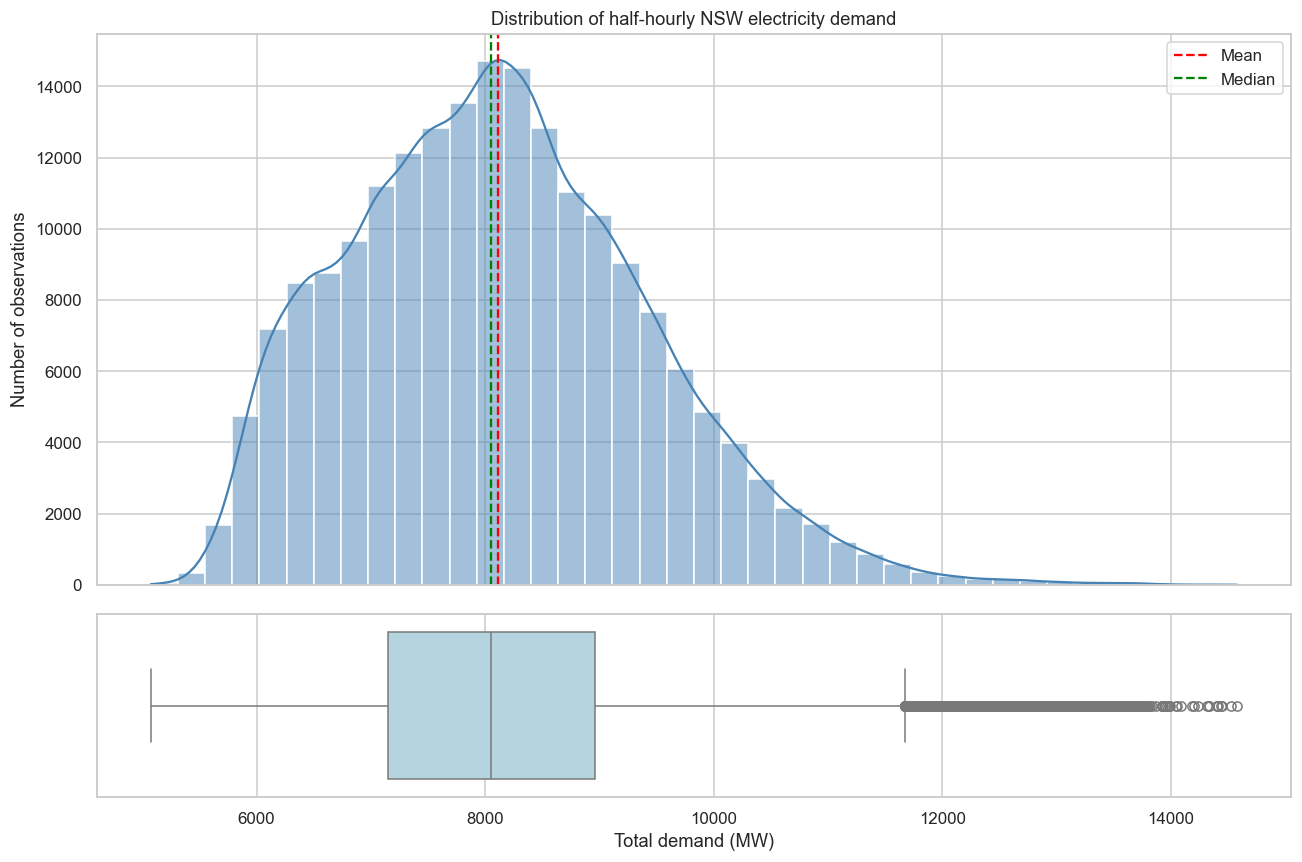

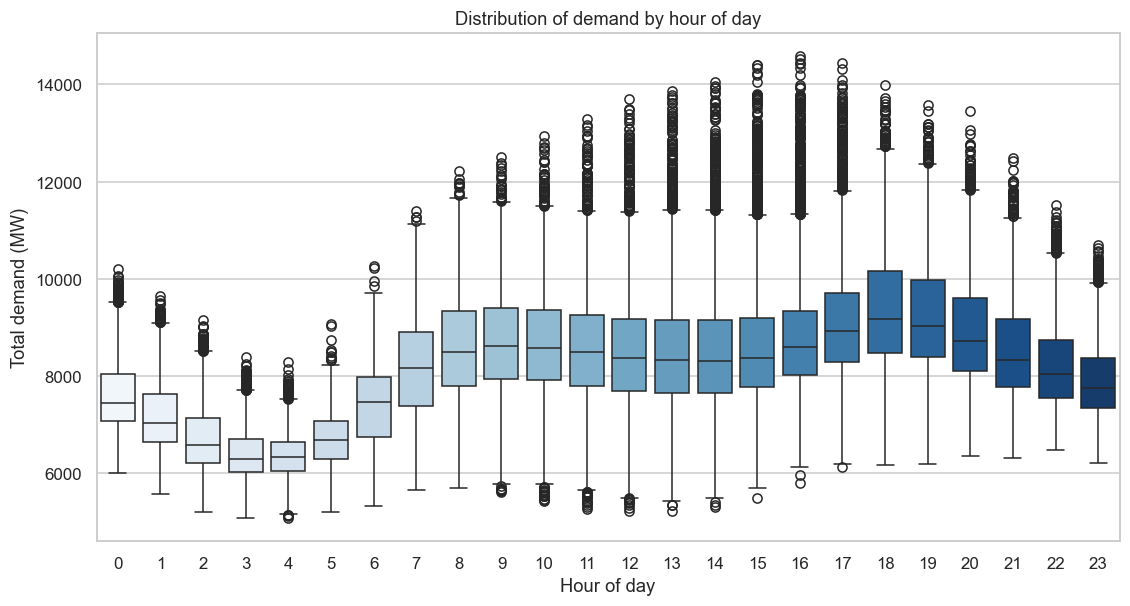

In [15]:
# Ensure DATETIME is datetime (safe even if already converted)
demand["DATETIME"] = pd.to_datetime(demand["DATETIME"])

fig, axes = plt.subplots(
    2, 1,
    figsize=(12, 8),
    gridspec_kw={"height_ratios": [3, 1]},
    sharex=True
)

sns.histplot(
    data=demand, x="TOTALDEMAND", bins=40, kde=True,
    ax=axes[0], color="steelblue"
)
axes[0].axvline(
    demand["TOTALDEMAND"].mean(), color="red", linestyle="--", label="Mean"
)
axes[0].axvline(
    demand["TOTALDEMAND"].median(), color="green", linestyle="--",
    label="Median"
)
axes[0].set_title("Distribution of half-hourly NSW electricity demand")
axes[0].set_ylabel("Number of observations")
axes[0].legend()

sns.boxplot(data=demand, x="TOTALDEMAND", ax=axes[1], color="lightblue")
axes[1].set_xlabel("Total demand (MW)")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

# Distribution by hour of day
plt.figure(figsize=(12, 6))
sns.boxplot(
    data=demand,
    x=demand["DATETIME"].dt.hour,
    y="TOTALDEMAND",
    palette="Blues"
)
plt.title("Distribution of demand by hour of day")
plt.xlabel("Hour of day")
plt.ylabel("Total demand (MW)")
plt.show()

**Figure 1.** Distribution of half-hourly NSW electricity demand, January
2010 to March 2021, shown as a histogram with kernel density estimate and
as a boxplot on a shared axis.

### Finding

Figure 1 shows a broad, approximately unimodal distribution centred near 8,000 MW, with an extended upper tail reaching beyond 14,000 MW. The mean lies slightly above the median, consistent with the mild positive skewness reported in Table 1.

The boxplot identifies a cluster of unusually high observations above roughly 11,700 MW, while no observations fall below the lower whisker. These high‑demand values may represent genuine peak‑demand events or potential data‑quality issues, and are examined further in Section 2.3.

The additional boxplot by hour of day shows clear intra‑day structure: demand is lowest overnight, rises sharply during the morning, and peaks in the late afternoon and early evening. This pattern confirms that demand belongs to distinct intra‑day regimes, and that unusually high or low observations must be interpreted relative to the time of day in which they occur. This motivates the time‑slot‑specific outlier rule introduced in Section 2.3.

### 2.3 Outliers

Two complementary rules are applied and compared. The first uses the standard interquartile range rule on the pooled demand series. The second standardises demand within each half‑hour interval of the day, so an observation is assessed relative to the normal demand level at that particular time.

This comparison is important because the pooled distribution has a structural blind spot. For example, a demand value of 5,100 MW may be ordinary at 4:00 a.m. but highly unusual at 6:00 p.m. A rule fitted only to the pooled distribution cannot distinguish between these time‑specific conditions. In addition, extreme‑demand observations often coincide with extreme temperature conditions, so both rules are examined alongside temperature to determine whether flagged observations represent genuine peak‑demand events.

In [23]:
# Rule 1: Pooled IQR rule
q1, q3 = demand["TOTALDEMAND"].quantile([0.25, 0.75])
iqr = q3 - q1
lower_bound, upper_bound = q1 - 1.5 * iqr, q3 + 1.5 * iqr

demand["FLAG_POOLED"] = (
    (demand["TOTALDEMAND"] < lower_bound)
    | (demand["TOTALDEMAND"] > upper_bound)
)

# Rule 2: Z score within each half-hour slot
slot = demand["DATETIME"].dt.hour + demand["DATETIME"].dt.minute / 60
by_slot = demand.groupby(slot)["TOTALDEMAND"]

demand["Z_BY_SLOT"] = (
    (demand["TOTALDEMAND"] - by_slot.transform("mean"))
    / by_slot.transform("std")
)
demand["FLAG_BY_SLOT"] = demand["Z_BY_SLOT"].abs() > 3

# Comparison table
comparison = pd.DataFrame({
    "Pooled IQR rule": [
        (demand["TOTALDEMAND"] < lower_bound).sum(),
        (demand["TOTALDEMAND"] > upper_bound).sum(),
        demand["FLAG_POOLED"].sum(),
        demand["FLAG_POOLED"].mean() * 100,
    ],
    "Z score within time slot": [
        (demand["Z_BY_SLOT"] < -3).sum(),
        (demand["Z_BY_SLOT"] > 3).sum(),
        demand["FLAG_BY_SLOT"].sum(),
        demand["FLAG_BY_SLOT"].mean() * 100,
    ],
}, index=["Flagged low", "Flagged high", "Flagged total", "Per cent of data"])

print(f"Pooled bounds: {lower_bound:,.2f} MW to {upper_bound:,.2f} MW")
print("Flagged by both rules:", (demand["FLAG_POOLED"] & demand["FLAG_BY_SLOT"]).sum())
print("Flagged only by the time slot rule:",
      (~demand["FLAG_POOLED"] & demand["FLAG_BY_SLOT"]).sum())

print("\nTable 2. Outliers found by each rule.")
display(comparison.round(2))


Pooled bounds: 4,437.35 MW to 11,671.27 MW
Flagged by both rules: 704
Flagged only by the time slot rule: 188

Table 2. Outliers found by each rule.


,Pooled IQR rule,Z score within time slot
Flagged low,0.00,3.00
Flagged high,1415.00,889.00
Flagged total,1415.00,892.00
Per cent of data,0.72,0.45


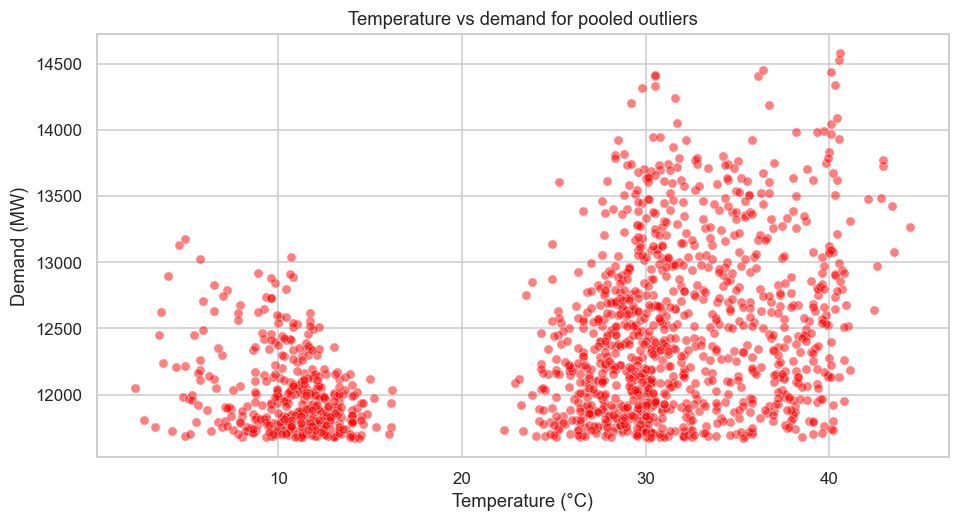

In [19]:
flagged = demand[demand["FLAG_POOLED"]]

plt.figure(figsize=(10, 5))
sns.scatterplot(
    data=flagged,
    x="TEMPERATURE",
    y="TOTALDEMAND",
    color="red",
    alpha=0.5
)
plt.title("Temperature vs demand for pooled outliers")
plt.xlabel("Temperature (°C)")
plt.ylabel("Demand (MW)")
plt.show()

**Figure 1.** Temperature vs demand for observations flagged by the pooled interquartile range rule.

In [20]:
# Seasonal distribution (top 5 months)
by_month = (
    flagged["DATETIME"].dt.month_name()
    .value_counts().head(5).rename_axis("Month").to_frame("Flagged")
)

# Time-of-day distribution
hour_band = pd.cut(
    flagged["DATETIME"].dt.hour,
    bins=[-1, 5, 11, 17, 23],
    labels=["Midnight to 5am", "6am to 11am", "Noon to 5pm", "6pm to 11pm"]
).rename("Time of day")

print("Table 3a. Pooled flags by time of day.")
display(hour_band.value_counts().sort_index().to_frame("Flagged"))

print("Table 3b. Pooled flags by month, top five.")
display(by_month)

Table 3a. Pooled flags by time of day.


,Flagged
Time of day,
Midnight to 5am,0
6am to 11am,116
Noon to 5pm,748
6pm to 11pm,551


Table 3b. Pooled flags by month, top five.


,Flagged
Month,
January,576
February,357
July,183
June,163
December,49


Table 3c. Run length profile of the pooled flags.


,Value
Number of separate runs,213.0
Isolated single intervals,24.0
Runs of 3 hours or longer,84.0
Longest run (intervals),26.0
Share of flagged rows in runs of 3 hours or longer (%),74.2



Every observation the time slot rule flags as unusually low:


,DATETIME,TOTALDEMAND,Z_BY_SLOT
0,2020-10-11 10:00:00,5478.43,-3.02
1,2020-10-11 10:30:00,5435.75,-3.01
2,2020-10-11 11:00:00,5299.85,-3.04


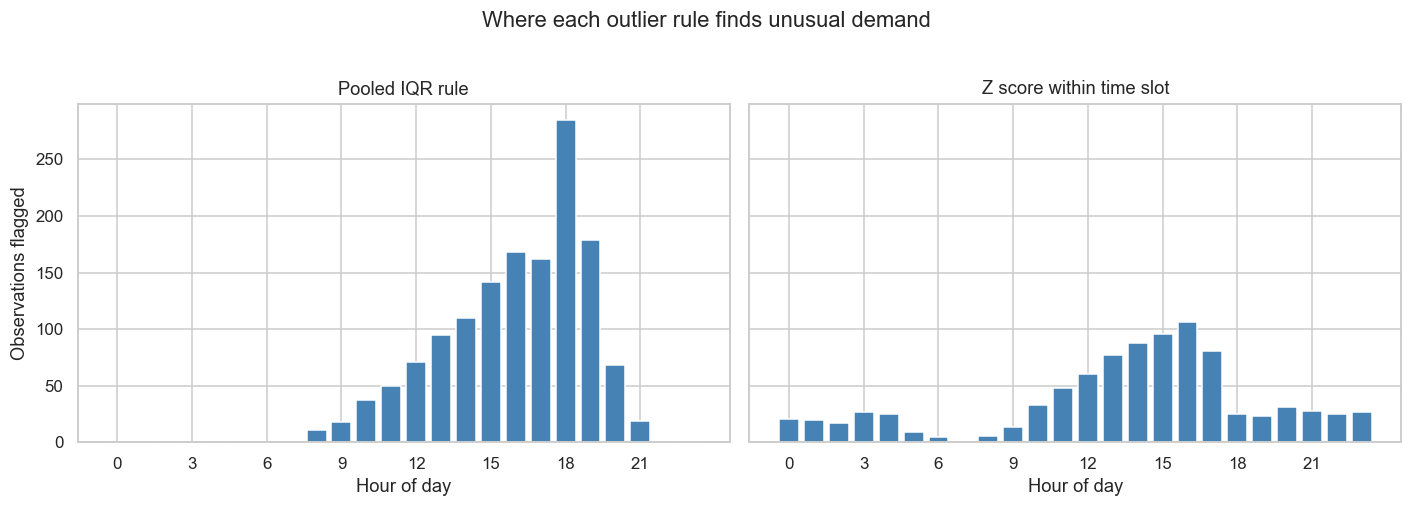

In [22]:
# Run-length analysis
run_id = (demand["FLAG_POOLED"] != demand["FLAG_POOLED"].shift()).cumsum()
run_lengths = (
    demand[demand["FLAG_POOLED"]].groupby(run_id[demand["FLAG_POOLED"]]).size()
)

run_profile = pd.Series({
    "Number of separate runs": len(run_lengths),
    "Isolated single intervals": (run_lengths == 1).sum(),
    "Runs of 3 hours or longer": (run_lengths >= 6).sum(),
    "Longest run (intervals)": run_lengths.max(),
    "Share of flagged rows in runs of 3 hours or longer (%)":
        run_lengths[run_lengths >= 6].sum() / run_lengths.sum() * 100,
}).round(1)

print("Table 3c. Run length profile of the pooled flags.")
display(run_profile.to_frame("Value"))

# Low-demand observations flagged by time-slot rule
print("\nEvery observation the time slot rule flags as unusually low:")
display(
    demand.loc[demand["Z_BY_SLOT"] < -3,
               ["DATETIME", "TOTALDEMAND", "Z_BY_SLOT"]]
    .round(2).reset_index(drop=True)
)

# Hour-of-day comparison plot
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)

for ax, col, name in zip(
    axes,
    ["FLAG_POOLED", "FLAG_BY_SLOT"],
    ["Pooled IQR rule", "Z score within time slot"]
):
    counts = (
        demand[demand[col]]["DATETIME"].dt.hour
        .value_counts().reindex(range(24), fill_value=0).sort_index()
    )
    ax.bar(counts.index, counts.values, color="steelblue")
    ax.set_title(name)
    ax.set_xlabel("Hour of day")
    ax.set_xticks(range(0, 24, 3))

axes[0].set_ylabel("Observations flagged")
fig.suptitle("Where each outlier rule finds unusual demand", y=1.02)
plt.tight_layout()
plt.show()

**Figure 2.** Count of observations flagged as unusual by hour of day under the pooled interquartile range rule and under the time‑slot z‑score rule.

### Finding


The two outlier rules identify different but complementary patterns. The pooled IQR rule flags 1,415 observations, representing 0.72% of the dataset, and all are unusually high. Figure 2 shows that these observations occur between 8:00 a.m. and 9:00 p.m. because overnight demand remains above the pooled lower boundary and therefore cannot be identified as unusually low by this method.

Tables 3a and 3b show that the pooled outliers are concentrated during summer and winter daytime periods, particularly in January and February. Table 3c provides evidence that most represent sustained demand events rather than isolated observations. The 1,415 flagged observations form 213 separate runs, and only 24 are isolated half-hour intervals. Approximately 74.2% belong to runs lasting at least three hours, while the longest event continues for 13 hours. This temporal clustering supports retaining them as likely genuine peak-demand events.

The time-specific rule identifies 892 observations, including 188 that are not detected by the pooled rule and mainly occur between 9:00 p.m. and 6:00 a.m. It also identifies only three unusually low observations, all occurring consecutively on the morning of 11 October 2020. Because these observations are concentrated on one date, their context should be investigated using additional contextual information before drawing conclusions about their cause.

Both outlier indicators are retained as analytical variables, but no observations are removed. Extreme-demand periods are important to the research question because forecasting models must be evaluated under difficult high-demand conditions rather than only under typical demand levels.

## 3. Time-based features

Time‑based features are created to examine recurring daily, weekly and annual demand patterns. Seasons follow the Southern Hemisphere calendar, and weekday/weekend status is derived from the day of the week.

Demand is also divided into three approximately equal‑sized categories using pooled demand tertiles. These low, medium and high categories are used only for descriptive analysis and model evaluation. They must not be used as predictor variables because they are calculated directly from the target variable, `TOTALDEMAND`.

In [26]:
demand["HOUR"] = (
    demand["DATETIME"].dt.hour + demand["DATETIME"].dt.minute / 60
)
demand["WEEKDAY"] = demand["DATETIME"].dt.day_name()
demand["DAY_NUMBER"] = demand["DATETIME"].dt.dayofweek
demand["MONTH"] = demand["DATETIME"].dt.month
demand["MONTH_NAME"] = demand["DATETIME"].dt.month_name()
demand["YEAR"] = demand["DATETIME"].dt.year
demand["DATE"] = demand["DATETIME"].dt.date
demand["IS_WEEKEND"] = demand["DAY_NUMBER"] >= 5
demand["DAY_TYPE"] = np.where(demand["IS_WEEKEND"], "Weekend", "Weekday")

# Southern hemisphere seasons
season_map = {
    12: "Summer", 1: "Summer", 2: "Summer",
    3: "Autumn", 4: "Autumn", 5: "Autumn",
    6: "Winter", 7: "Winter", 8: "Winter",
    9: "Spring", 10: "Spring", 11: "Spring",
}
demand["SEASON"] = demand["MONTH"].map(season_map)

# Demand tertiles (for descriptive use only)
demand["DEMAND_LEVEL"] = pd.qcut(
    demand["TOTALDEMAND"], q=3, labels=["Low", "Medium", "High"]
)

season_order = ["Summer", "Autumn", "Winter", "Spring"]
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday",
             "Friday", "Saturday", "Sunday"]
month_order = ["January", "February", "March", "April", "May", "June",
               "July", "August", "September", "October", "November",
               "December"]

demand.head()

,DATETIME,TOTALDEMAND,REGIONID,LOCATION,TEMPERATURE,forecast_closest,forecast_12hr_prior,forecast_dayprior,year,month,day,radiation,is_public_holiday,is_school_term,day_of_week,FLAG_POOLED,Z_BY_SLOT,FLAG_BY_SLOT,HOUR,WEEKDAY,DAY_NUMBER,MONTH,MONTH_NAME,YEAR,DATE,IS_WEEKEND,DAY_TYPE,SEASON,DEMAND_LEVEL
0,2010-01-01 00:00:00,8038.00,NSW1,Bankstown,23.1,7999.11,7811.86,7822.38,2010,1,1,14.6,True,False,Friday,False,0.495106,False,0.0,Friday,4,1,January,2010,2010-01-01,False,Weekday,Summer,Medium
1,2010-01-01 00:30:00,7809.31,NSW1,Bankstown,22.9,7596.21,7612.63,7715.68,2010,1,1,14.6,True,False,Friday,False,0.471763,False,0.5,Friday,4,1,January,2010,2010-01-01,False,Weekday,Summer,Medium
2,2010-01-01 01:00:00,7483.69,NSW1,Bankstown,22.6,7380.70,7339.64,7482.56,2010,1,1,14.6,True,False,Friday,False,0.292793,False,1.0,Friday,4,1,January,2010,2010-01-01,False,Weekday,Summer,Medium
3,2010-01-01 01:30:00,7117.23,NSW1,Bankstown,22.5,7022.05,7009.55,7129.32,2010,1,1,14.6,True,False,Friday,False,0.100196,False,1.5,Friday,4,1,January,2010,2010-01-01,False,Weekday,Summer,Low
4,2010-01-01 02:00:00,6812.03,NSW1,Bankstown,22.5,6682.92,6683.15,6800.73,2010,1,1,14.6,True,False,Friday,False,-0.023254,False,2.0,Friday,4,1,January,2010,2010-01-01,False,Weekday,Summer,Low


In [27]:
level_ranges = (
    demand.groupby("DEMAND_LEVEL", observed=True)["TOTALDEMAND"]
    .agg(observations="count", minimum="min", maximum="max", average="mean")
)

print("Observations per season:")
print(demand["SEASON"].value_counts())

print("\nTable 4. Demand ranges used for each level.")
level_ranges.round(2)

Observations per season:
SEASON
Summer    50496
Autumn    49393
Winter    48576
Spring    48048
Name: count, dtype: int64

Table 4. Demand ranges used for each level.


,observations,minimum,maximum,average
DEMAND_LEVEL,,,,
Low,65505,5074.63,7475.48,6722.18
Medium,65504,7475.49,8605.99,8045.68
High,65504,8606.02,14579.86,9571.60


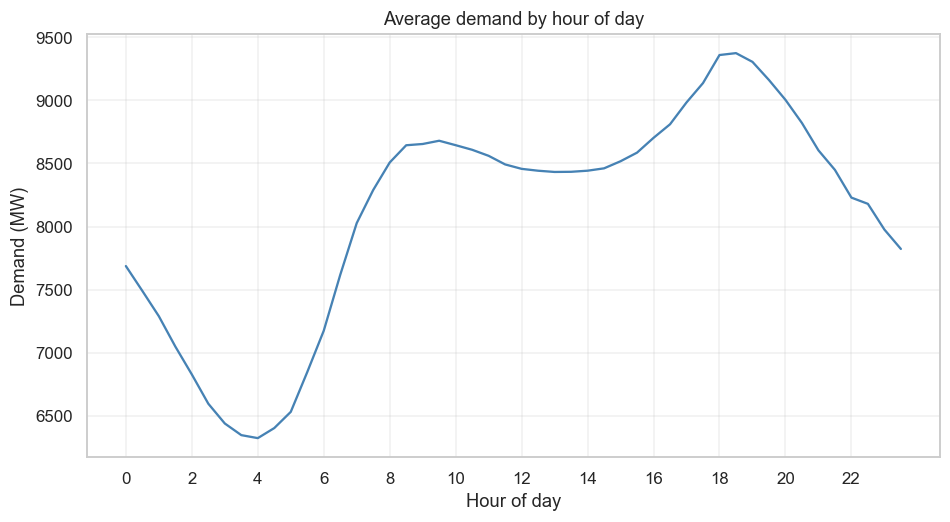

In [31]:
# Average demand by hour of day
hourly_profile = (
    demand.groupby("HOUR", observed=True)["TOTALDEMAND"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(10, 5))
sns.lineplot(data=hourly_profile, x="HOUR", y="TOTALDEMAND", color="steelblue")
plt.title("Average demand by hour of day")
plt.xlabel("Hour of day")
plt.ylabel("Demand (MW)")
plt.xticks(range(0, 24, 2))
plt.grid(alpha=0.3)
plt.show()

**Figure 1.** Average NSW electricity demand by hour of day, January 2010 to March 2021.

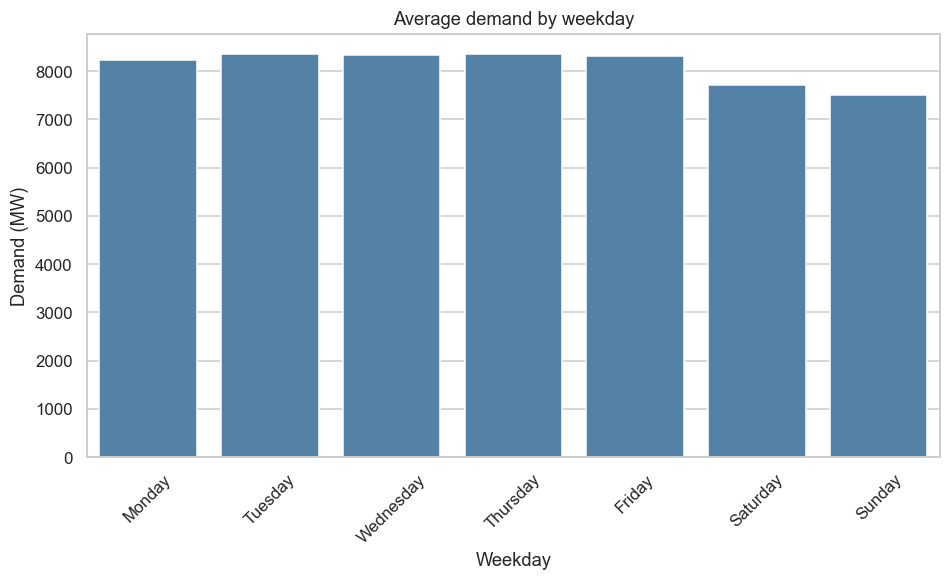

In [32]:
# Average demand by weekday
weekday_profile = (
    demand.groupby("WEEKDAY", observed=True)["TOTALDEMAND"]
    .mean()
    .reindex(day_order)
    .reset_index()
)

plt.figure(figsize=(10, 5))
sns.barplot(data=weekday_profile, x="WEEKDAY", y="TOTALDEMAND", color="steelblue")
plt.title("Average demand by weekday")
plt.xlabel("Weekday")
plt.ylabel("Demand (MW)")
plt.xticks(rotation=45)
plt.show()

**Figure 2.** Average NSW electricity demand by weekday, January 2010 to March 2021.

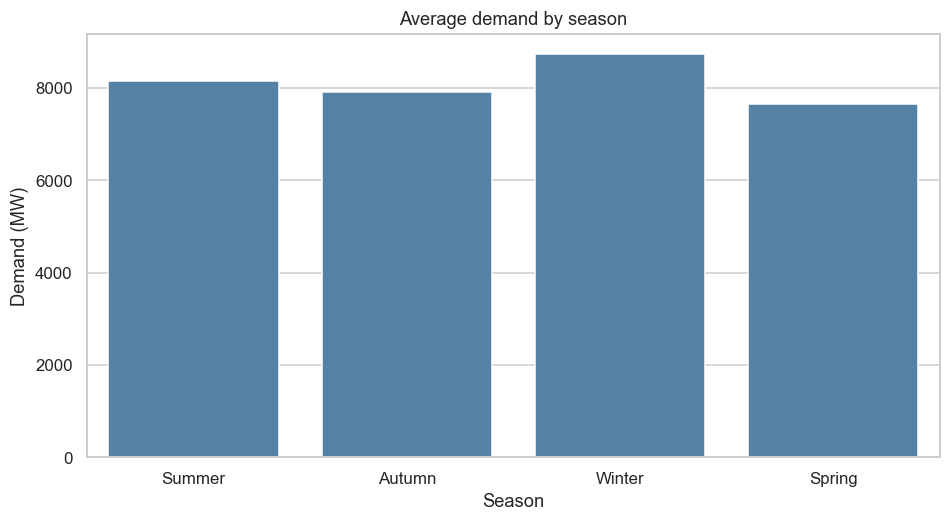

In [33]:
# Average demand by season
season_profile = (
    demand.groupby("SEASON", observed=True)["TOTALDEMAND"]
    .mean()
    .reindex(season_order)
    .reset_index()
)

plt.figure(figsize=(10, 5))
sns.barplot(data=season_profile, x="SEASON", y="TOTALDEMAND", color="steelblue")
plt.title("Average demand by season")
plt.xlabel("Season")
plt.ylabel("Demand (MW)")
plt.show()

**Figure 3.** Average NSW electricity demand by weekday, January 2010 to March 2021.

### Finding

Electricity demand exhibits clear and recurring temporal structure across daily, weekly and seasonal cycles. Average demand is lowest overnight, rising sharply from around 6:00 a.m. and peaking between 5:00 p.m. and 7:00 p.m., as shown in Figure 1. This pattern reflects typical residential and commercial activity, with morning ramp‑up and strong evening peaks.

Weekly patterns are also evident. Figure 2 shows that demand is consistently higher on weekdays than weekends, with Saturday and Sunday exhibiting noticeably lower average demand. This aligns with reduced commercial and industrial activity during weekends.

Seasonal variation is substantial. Figure 3 shows that winter has the highest average demand, followed by summer, reflecting heating and cooling requirements. Autumn and spring have lower average demand, consistent with milder temperatures and reduced climate‑driven load.

Demand tertiles provide a simple descriptive categorisation of low, medium and high demand conditions. Table 4 shows that low‑demand observations fall between approximately 5,075 MW and 7,475 MW, medium‑demand observations between 7,475 MW and 8,606 MW, and high‑demand observations above 8,606 MW. These categories are used only for descriptive analysis and model evaluation because they are derived directly from the target variable.

Together, these temporal features highlight strong intra‑day, weekly and seasonal structure in electricity demand. They provide essential context for model specification, ensuring that forecasting models account for recurring patterns that systematically influence demand.

## 4. How the demand levels relate to year and season

The three demand levels come from a quantile cut on the pooled series, so
each holds roughly 65,500 observations. That definition is convenient but
it is not neutral, and it is worth checking what ends up inside each
group before those groups are used to report model accuracy.

In [15]:
level_by_year = pd.crosstab(
    demand["YEAR"], demand["DEMAND_LEVEL"], normalize="index"
) * 100

level_by_season = pd.crosstab(
    demand["SEASON"], demand["DEMAND_LEVEL"], normalize="index"
) * 100

print("Table 5. Composition of each year by demand level (row per cent).")
display(level_by_year.round(1))
print("Table 6. Composition of each season by demand level (row per cent).")
display(level_by_season.reindex(season_order).round(1))

Table 5. Composition of each year by demand level (row per cent).


DEMAND_LEVEL,Low,Medium,High
YEAR,,,
2010,19.3,23.6,57.0
2011,19.7,25.3,55.0
2012,28.6,30.9,40.5
2013,34.5,35.7,29.7
2014,35.4,36.5,28.1
2015,35.3,35.4,29.3
2016,35.8,36.3,27.9
2017,33.8,37.2,28.9
2018,34.0,38.8,27.2


Table 6. Composition of each season by demand level (row per cent).


DEMAND_LEVEL,Low,Medium,High
SEASON,,,
Summer,35.0,29.9,35.1
Autumn,36.5,36.1,27.4
Winter,18.7,27.3,53.9
Spring,43.1,40.2,16.7


### Finding

Table 5 shows that the composition of the pooled demand‑level categories changes substantially over time. In 2010, 57.0% of half‑hourly observations fall within the High category and only 19.3% fall within the Low category. By 2020, this pattern reverses: the High proportion falls to 21.1%, while the Low proportion rises to 48.4%. The partial 2021 period is even more uneven, although it should be interpreted cautiously because it contains only part of the calendar year.

This shift reflects the 12.46% decline in average demand between 2010 and 2020. Because the category boundaries are calculated from the pooled dataset and remain fixed across all years, observations from earlier high‑demand years are more likely to be classified as High, while observations from later lower‑demand years are more likely to be classified as Low.

Table 6 shows a similar relationship with season. Approximately 53.9% of winter observations fall within the High category, compared with only 16.7% of spring observations. The pooled demand‑level categories therefore capture both absolute demand magnitude and part of the underlying year and seasonal effects.

This has important implications for model evaluation. The pooled categories can still be used to compare forecasting accuracy at consistent absolute demand levels, but they should not be treated as independent of year or season. As a robustness check, evaluation results should be reported using both pooled demand levels and within‑year demand levels. This helps determine whether changes in model accuracy are genuinely associated with demand magnitude rather than structural differences between earlier and later years.

## 5. Daily load profile

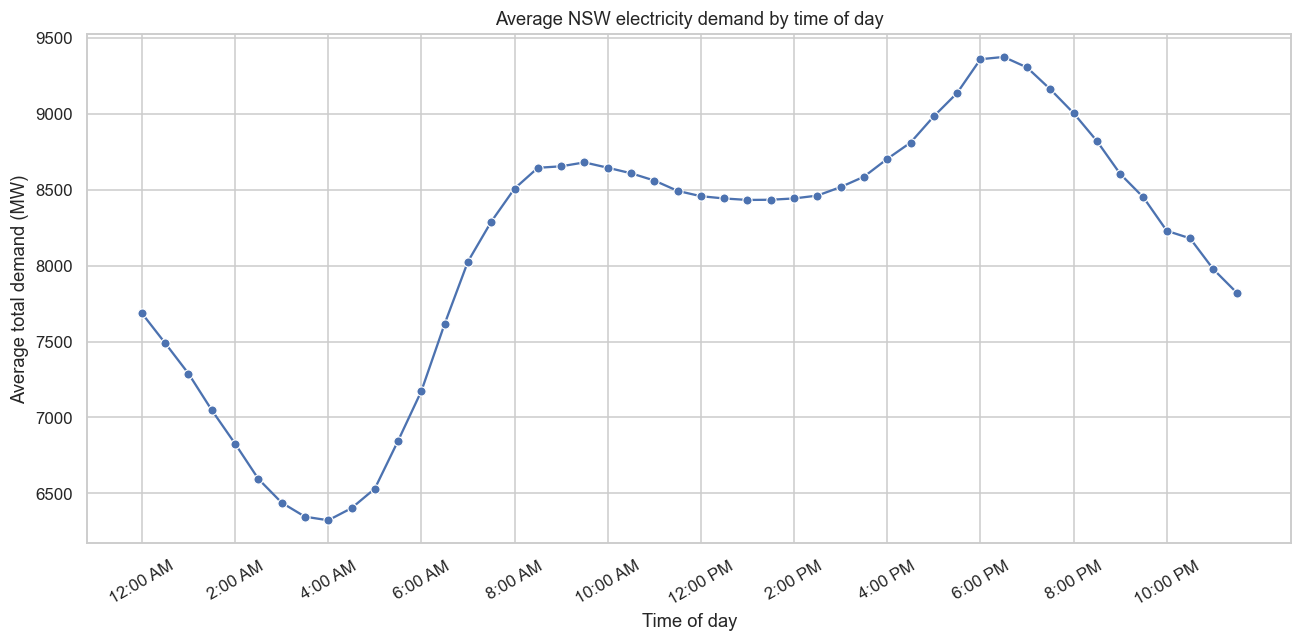

Trough: 6,322.69 MW at 4:00 AM
Peak: 9,375.04 MW at 6:30 PM


In [35]:
def format_time(hour):
    timestamp = (
        pd.Timestamp("2000-01-01")
        + pd.to_timedelta(hour, unit="h")
    )
    return timestamp.strftime("%I:%M %p").lstrip("0")


hourly_profile = (
    demand.groupby("HOUR")["TOTALDEMAND"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=hourly_profile,
    x="HOUR",
    y="TOTALDEMAND",
    marker="o"
)

tick_hours = range(0, 24, 2)

plt.xticks(
    tick_hours,
    [format_time(hour) for hour in tick_hours],
    rotation=30
)

plt.title("Average NSW electricity demand by time of day")
plt.xlabel("Time of day")
plt.ylabel("Average total demand (MW)")
plt.tight_layout()
plt.show()

lowest = hourly_profile.loc[
    hourly_profile["TOTALDEMAND"].idxmin()
]

highest = hourly_profile.loc[
    hourly_profile["TOTALDEMAND"].idxmax()
]

print(
    f"Trough: {lowest['TOTALDEMAND']:,.2f} MW at "
    f"{format_time(lowest['HOUR'])}"
)

print(
    f"Peak: {highest['TOTALDEMAND']:,.2f} MW at "
    f"{format_time(highest['HOUR'])}"
)


**Figure 1.** Average NSW electricity demand by half hour of the day,
averaged over the full sample.

### Finding

Figure 1. shows a clear daily electricity‑demand cycle. Average demand reaches its lowest level of 6,322.69 MW at approximately 4:00 a.m., then rises sharply during the morning. Demand remains comparatively stable through the middle of the day before increasing again during the late afternoon.

The highest average demand of 9,375.04 MW occurs at 6:30 p.m., approximately 48.3% above the early‑morning trough. Demand then declines throughout the evening. This pronounced variation indicates that time of day contains important forecasting information and should be represented in the models through appropriate hourly or cyclical time features.

### 5.1 The daily shape by season

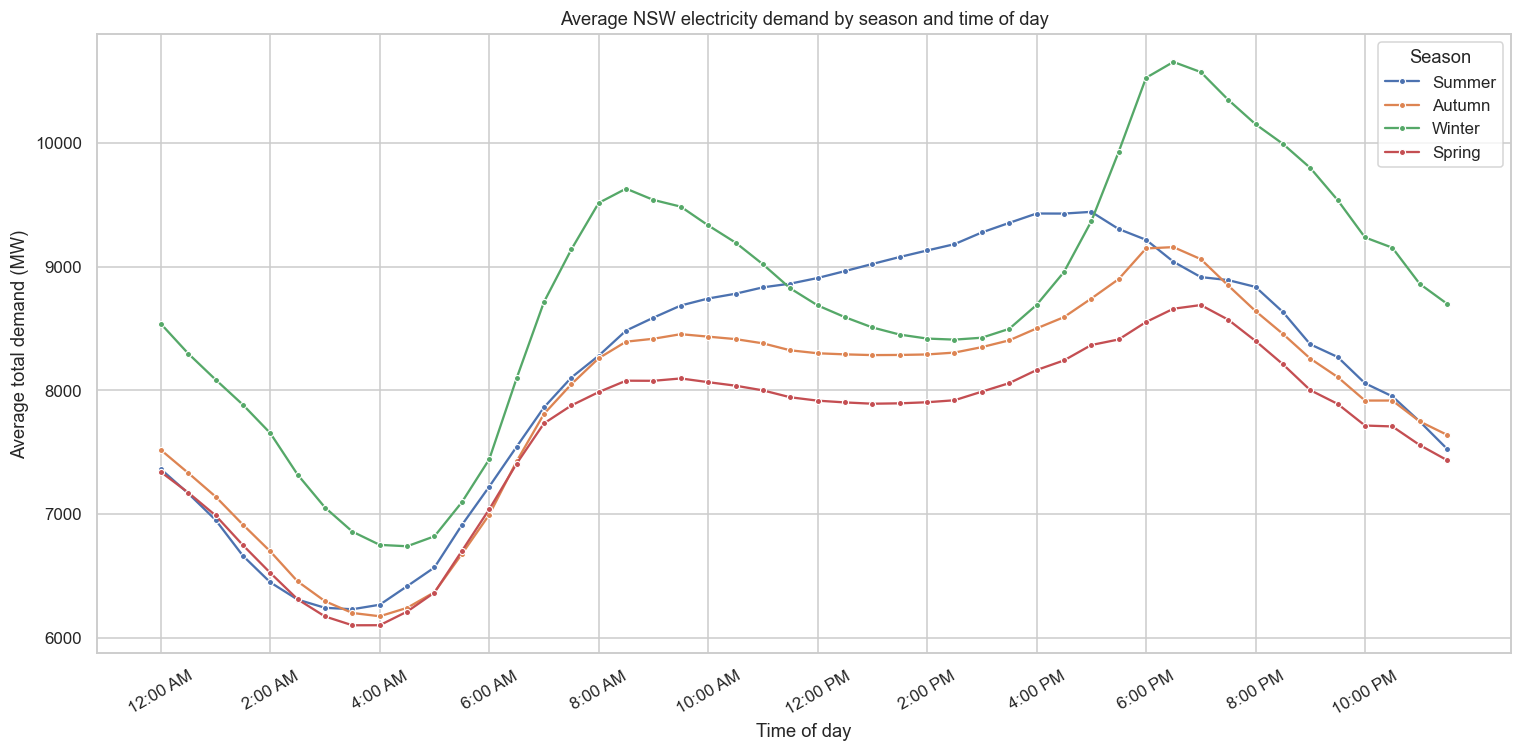

In [36]:
seasonal_hourly = (
    demand.groupby(["SEASON", "HOUR"], observed=True)["TOTALDEMAND"]
    .mean().reset_index()
)

plt.figure(figsize=(14, 7))
sns.lineplot(
    data=seasonal_hourly, x="HOUR", y="TOTALDEMAND",
    hue="SEASON", hue_order=season_order, marker="o", markersize=4
)
plt.xticks(
    range(0, 24, 2),
    [format_time(h) for h in range(0, 24, 2)],
    rotation=30
)
plt.title("Average NSW electricity demand by season and time of day")
plt.xlabel("Time of day")
plt.ylabel("Average total demand (MW)")
plt.legend(title="Season")
plt.tight_layout()
plt.show()

**Figure 2.** Average NSW electricity demand by season and time of day.

In [37]:
rows = []
for season in season_order:
    block = seasonal_hourly[seasonal_hourly["SEASON"] == season]
    low = block.loc[block["TOTALDEMAND"].idxmin()]
    high = block.loc[block["TOTALDEMAND"].idxmax()]
    rows.append({
        "Season": season,
        "Average demand (MW)":
            demand.loc[demand["SEASON"] == season, "TOTALDEMAND"].mean(),
        "Trough (MW)": low["TOTALDEMAND"],
        "Trough time": format_time(low["HOUR"]),
        "Peak (MW)": high["TOTALDEMAND"],
        "Peak time": format_time(high["HOUR"]),
        "Peak over trough (%)":
            (high["TOTALDEMAND"] / low["TOTALDEMAND"] - 1) * 100,
    })

seasonal_summary = pd.DataFrame(rows).set_index("Season")

print("Table 7. Seasonal load profile summary.")
seasonal_summary.round(2)

Table 7. Seasonal load profile summary.


,Average demand (MW),Trough (MW),Trough time,Peak (MW),Peak time,Peak over trough (%)
Season,,,,,,
Summer,8155.91,6230.65,3:30 AM,9442.20,5:00 PM,51.54
Autumn,7906.20,6173.81,4:00 AM,9157.12,6:30 PM,48.32
Winter,8738.86,6739.58,4:30 AM,10653.74,6:30 PM,58.08
Spring,7648.35,6100.99,3:30 AM,8688.93,7:00 PM,42.42


### Finding

Figure 5.2 shows that seasonal load profiles differ in both their overall demand levels and their daily shapes. Winter records the highest average demand and shows two distinct increases: a morning peak around 8:00–9:00 a.m. and a larger evening peak at 6:30 p.m. Summer differs from the other seasons because demand remains comparatively high during the afternoon and reaches its maximum earlier, at 5:00 p.m. Spring generally records the lowest daytime demand and reaches its evening peak later, at 7:00 p.m.

Table 7 confirms these graphical patterns. Winter has the highest seasonal average of 8,738.86 MW and the largest peak of 10,653.74 MW. Spring has the lowest average of 7,648.35 MW and a peak of 8,688.93 MW, making the winter peak approximately 1,965 MW higher. The lowest average demand occurs between 3:30 a.m. and 4:30 a.m. in every season, while the timing of the peak varies by up to two hours.

The peak‑to‑trough increase also varies across seasons, ranging from 42.42% in spring to 58.08% in winter. These results indicate that seasonal differences involve more than a simple upward or downward shift in demand. Forecasting models should therefore allow hour of day and season to interact so they can represent changes in both the timing and magnitude of demand peaks.

## 6. Weekly pattern

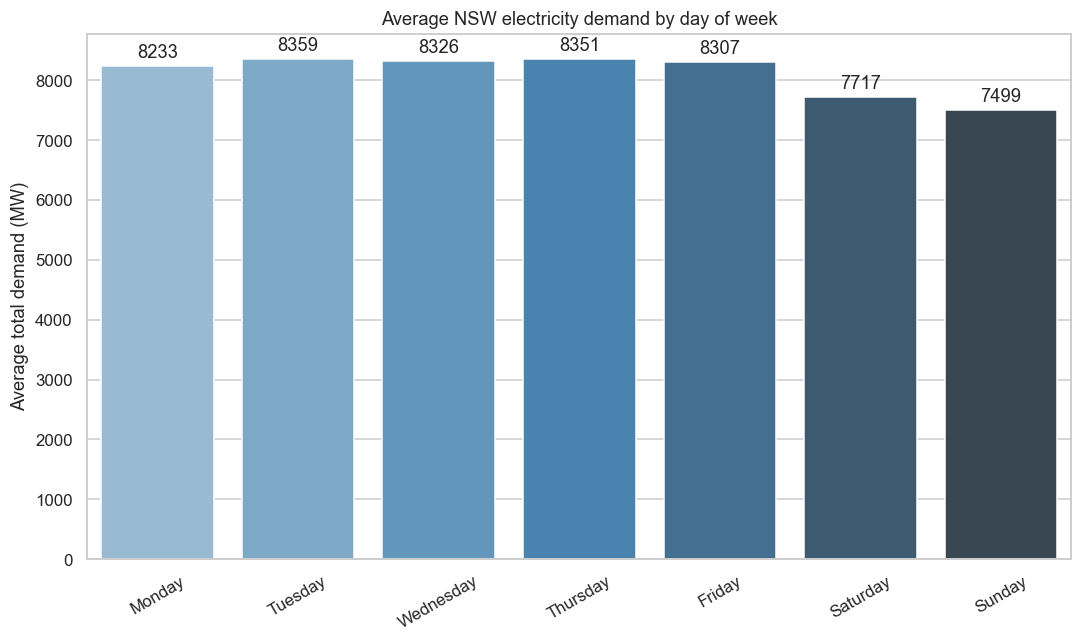

In [39]:
weekday_profile = (
    demand.groupby("WEEKDAY")["TOTALDEMAND"].mean()
    .reindex(day_order).reset_index()
)

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=weekday_profile, x="WEEKDAY", y="TOTALDEMAND",
    hue="WEEKDAY", palette="Blues_d", legend=False
)
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=3)

plt.title("Average NSW electricity demand by day of week")
plt.xlabel("")
plt.ylabel("Average total demand (MW)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


**Figure 1.** Average NSW electricity demand by day of the week.

In [40]:
weekday_mean = demand.loc[~demand["IS_WEEKEND"], "TOTALDEMAND"].mean()
weekend_mean = demand.loc[demand["IS_WEEKEND"], "TOTALDEMAND"].mean()

print("Table 8. Average demand by day of week.")
display(
    weekday_profile
    .rename(columns={"WEEKDAY": "Day", "TOTALDEMAND": "Average demand (MW)"})
    .round(2).set_index("Day")
)

print(f"Weekdays: {weekday_mean:,.2f} MW")
print(f"Weekends: {weekend_mean:,.2f} MW")
print(f"Difference:   {weekday_mean - weekend_mean:,.2f} MW "
      f"({(weekday_mean / weekend_mean - 1) * 100:.2f}%)")

Table 8. Average demand by day of week.


,Average demand (MW)
Day,
Monday,8233.07
Tuesday,8358.96
Wednesday,8326.01
Thursday,8351.03
Friday,8307.18
Saturday,7717.35
Sunday,7498.81


Weekdays: 8,315.24 MW
Weekends: 7,608.08 MW
Difference:   707.16 MW (9.29%)


### Finding

Figure 1 and Table 8 show that average demand remains relatively stable from Monday to Friday but decreases noticeably during the weekend. Weekday averages range from 8,233.07 MW on Monday to 8,358.96 MW on Tuesday, a difference of approximately 126 MW. Saturday demand falls to 7,717.35 MW, while Sunday records the lowest average of 7,498.81 MW.

Average weekday demand is 8,315.24 MW, compared with 7,608.08 MW during weekends — a difference of 707.16 MW, meaning weekday demand is approximately 9.29% higher than weekend demand.

These results indicate that weekday/weekend status contains useful forecasting information. Saturday and Sunday also differ by approximately 219 MW, so retaining the individual day‑of‑week categories may capture additional variation that a single weekend indicator would miss. The following subsection examines whether these differences also vary by time of day.

### 6.1 Day of week against time of day

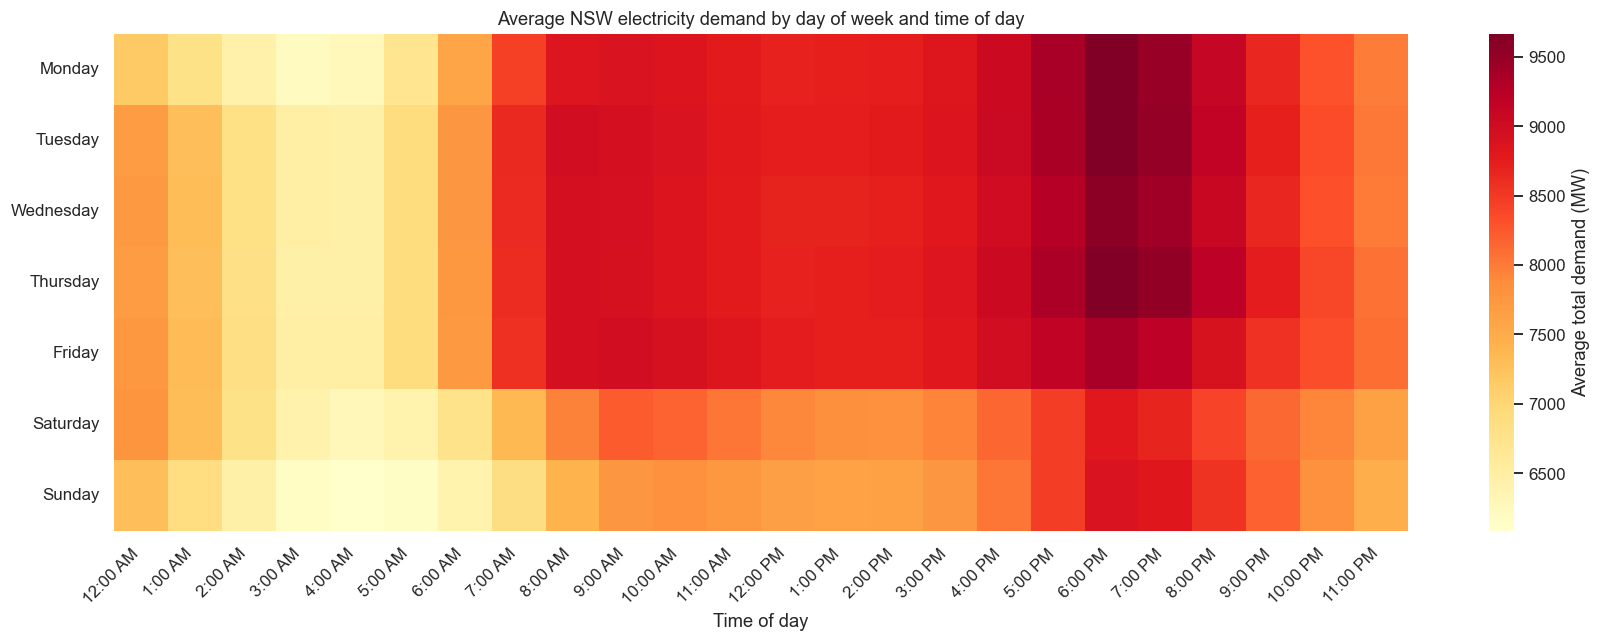

In [41]:
heatmap_data = (
    demand.assign(HOUR_OF_DAY=demand["DATETIME"].dt.hour)
    .pivot_table(
        index="WEEKDAY", columns="HOUR_OF_DAY",
        values="TOTALDEMAND", aggfunc="mean"
    )
    .reindex(day_order)
)

plt.figure(figsize=(16, 6))
sns.heatmap(
    heatmap_data, cmap="YlOrRd",
    xticklabels=[format_time(h) for h in range(24)],
    cbar_kws={"label": "Average total demand (MW)"}
)
plt.title("Average NSW electricity demand by day of week and time of day")
plt.xlabel("Time of day")
plt.ylabel("")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

**Figure 2.** Average NSW electricity demand by day of week and hourly time period. Darker cells indicate higher average demand.

In [42]:
weekday_hour_summary = pd.DataFrame({
    "Trough (MW)": heatmap_data.min(axis=1),
    "Trough time": heatmap_data.idxmin(axis=1).map(format_time),
    "Peak (MW)": heatmap_data.max(axis=1),
    "Peak time": heatmap_data.idxmax(axis=1).map(format_time),
}).reindex(day_order)

print("Table 9. Trough and peak by day of week.")
weekday_hour_summary.round(2)

Table 9. Trough and peak by day of week.


,Trough (MW),Trough time,Peak (MW),Peak time
WEEKDAY,,,,
Monday,6220.54,3:00 AM,9665.54,6:00 PM
Tuesday,6474.83,4:00 AM,9656.14,6:00 PM
Wednesday,6462.14,4:00 AM,9561.35,6:00 PM
Thursday,6466.60,4:00 AM,9640.08,6:00 PM
Friday,6487.59,4:00 AM,9362.18,6:00 PM
Saturday,6289.03,4:00 AM,8800.37,6:00 PM
Sunday,6083.88,4:00 AM,8887.25,6:00 PM


### Finding

Figure 1 shows a recurring daily demand cycle across all seven days, together with a clear reduction in demand during the weekend. From Monday to Friday, demand increases sharply during the morning and reaches its highest hourly average during the 6:00–6:59 p.m. period. Weekend demand follows a broadly similar daily pattern but remains lower, particularly during daytime hours.

Table 9 shows that Monday records the highest hourly peak at 9,665.54 MW, while Saturday has the lowest peak at 8,800.37 MW. Sunday records the lowest overnight trough at 6,083.88 MW. Most daily troughs occur during the 4:00–4:59 a.m. period, although Monday reaches its minimum during the preceding hour.

These results suggest that both hour of day and day of week provide useful forecasting information. Although the timing of the main evening peak is consistent across the week, its magnitude differs between weekdays and weekends. The following section examines whether this relationship also changes across seasons.

## 7. Season, day type and time of day together

Sections 5 and 6 examined seasonal and weekly patterns separately. This section puts season,
day type and time of day in the same view, which is the combination that
matters for the evaluation design: if the weekend effect were much larger
in winter than in spring, then season and day type could not be treated
as separate additive terms.

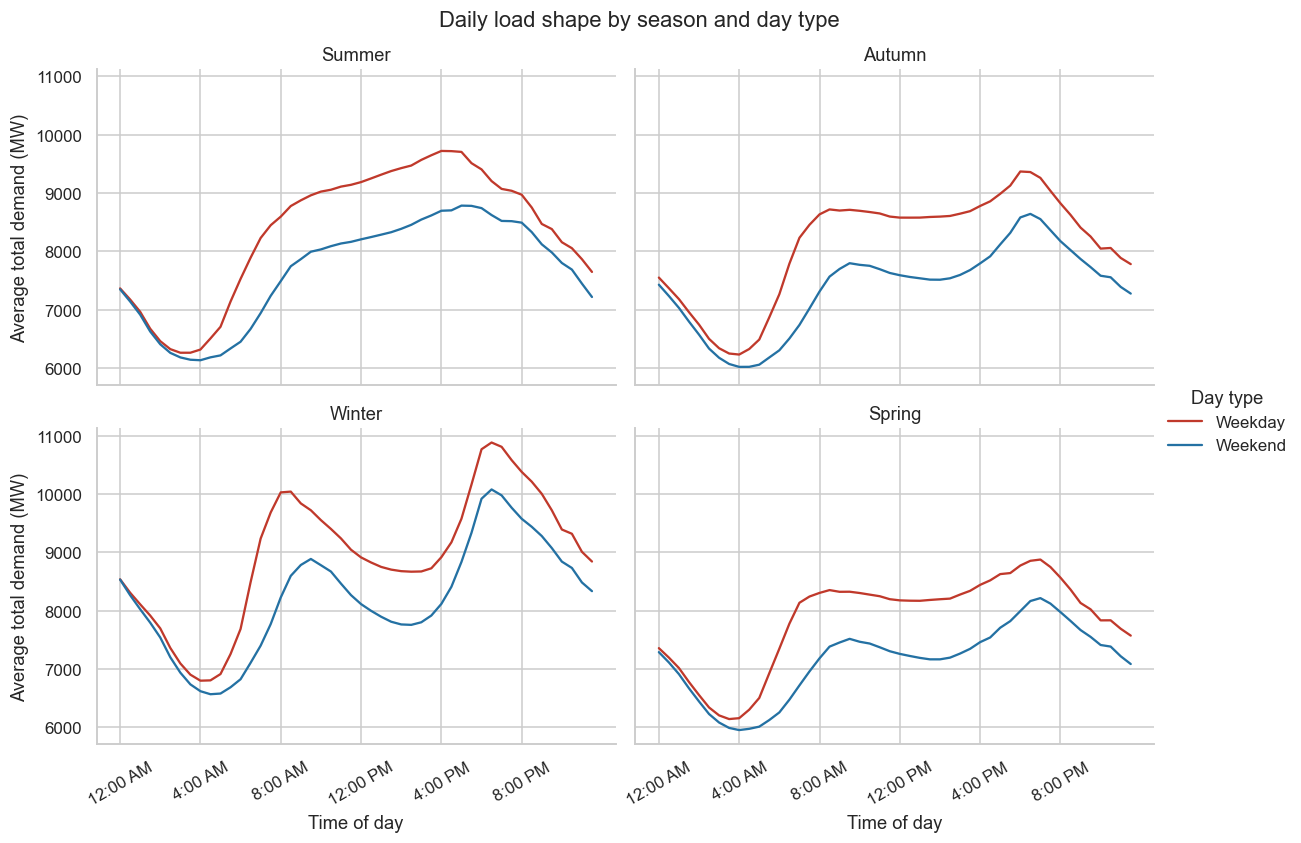

In [44]:
three_way = (
    demand.groupby(
        ["SEASON", "DAY_TYPE", "HOUR"],
        observed=True
    )["TOTALDEMAND"]
    .mean()
    .reset_index()
    .sort_values(["SEASON", "DAY_TYPE", "HOUR"])
)

grid = sns.relplot(
    data=three_way,
    x="HOUR",
    y="TOTALDEMAND",
    hue="DAY_TYPE",
    col="SEASON",
    col_order=season_order,
    kind="line",
    col_wrap=2,
    height=3.6,
    aspect=1.5,
    palette={
        "Weekday": "#C0392B",
        "Weekend": "#2471A3"
    }
)

grid.set_axis_labels(
    "Time of day",
    "Average total demand (MW)"
)

grid.set_titles("{col_name}")
grid._legend.set_title("Day type")

tick_hours = list(range(0, 24, 4))

for ax in grid.axes.flat:
    ax.set_xticks(tick_hours)
    ax.set_xticklabels(
        [format_time(hour) for hour in tick_hours],
        rotation=30
    )

grid.figure.suptitle(
    "Daily load shape by season and day type",
    y=1.02
)

plt.show()


**Figure 1.** Daily load shape by season and day type.

In [45]:
gap_rows = []
for season in season_order:
    block = three_way[three_way["SEASON"] == season]
    out = {"Season": season}
    for day_type in ["Weekday", "Weekend"]:
        sub = block[block["DAY_TYPE"] == day_type]
        peak = sub.loc[sub["TOTALDEMAND"].idxmax()]
        mean = demand.loc[
            (demand["SEASON"] == season) & (demand["DAY_TYPE"] == day_type),
            "TOTALDEMAND"
        ].mean()
        out[f"{day_type} mean (MW)"] = mean
        out[f"{day_type} peak (MW)"] = peak["TOTALDEMAND"]
        out[f"{day_type} peak time"] = format_time(peak["HOUR"])
    out["Gap (MW)"] = out["Weekday mean (MW)"] - out["Weekend mean (MW)"]
    out["Gap (%)"] = out["Gap (MW)"] / out["Weekend mean (MW)"] * 100
    gap_rows.append(out)

gap_table = (
    pd.DataFrame(gap_rows)
    .set_index("Season")
    .reindex(season_order)
)

print("Table 10. Weekday and weekend demand within each season.")
gap_table.round(2)

Table 10. Weekday and weekend demand within each season.


,Weekday mean (MW),Weekday peak (MW),Weekday peak time,Weekend mean (MW),Weekend peak (MW),Weekend peak time,Gap (MW),Gap (%)
Season,,,,,,,,
Summer,8350.14,9722.95,4:00 PM,7673.56,8786.01,5:00 PM,676.58,8.82
Autumn,8115.65,9370.73,6:00 PM,7380.06,8644.38,6:30 PM,735.59,9.97
Winter,8946.01,10883.43,6:30 PM,8220.63,10079.11,6:30 PM,725.39,8.82
Spring,7846.26,8877.66,7:00 PM,7153.57,8217.10,7:00 PM,692.69,9.68


**Figure 7.** Average daily load shape by season, with weekdays and weekends plotted separately in each panel.

### Finding

Figure 7 and Table 10 show that the weekday–weekend difference is reasonably consistent across seasons. Average weekday demand is between 8.82% and 9.97% higher than average weekend demand. The absolute difference ranges from 676.58 MW in summer to 735.59 MW in autumn. This suggests that day type produces a broadly consistent change in average demand across the year.

However, the timing and magnitude of peak demand vary by both season and day type. In summer, the weekday peak occurs at 4:00 p.m., while the weekend peak occurs one hour later at 5:00 p.m. In autumn, the weekend peak occurs 30 minutes later than the weekday peak. Winter and spring show no difference in peak timing between weekdays and weekends.

The reduction in peak demand also varies across seasons. The summer weekend peak is approximately 936.94 MW below the weekday peak, compared with a difference of approximately 804.32 MW in winter. Therefore, although a weekday/weekend indicator can represent much of the difference in average demand, interactions between hour of day, season and day type may help forecasting models represent changes in peak timing and magnitude. Model performance should consequently be evaluated separately across seasons and day types.

These patterns justify evaluating model performance separately by season and day type, particularly for peak‑demand periods where forecasting errors are most consequential.

## 8. Monthly and annual movement

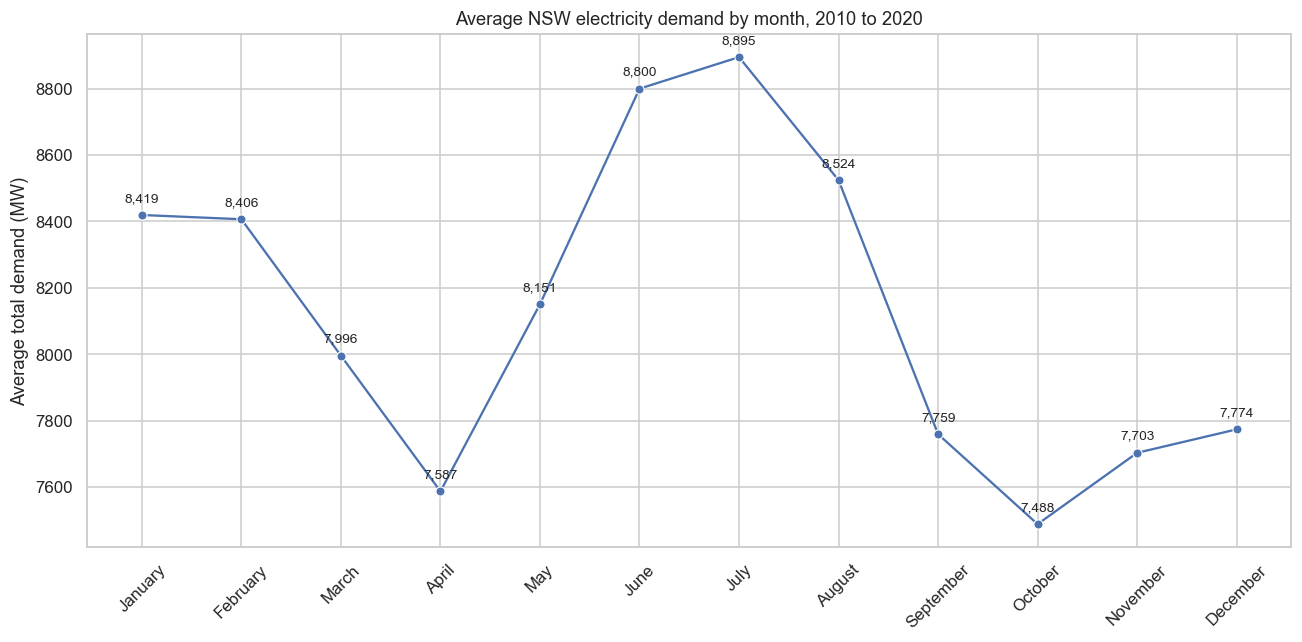

In [53]:
complete_years = demand[demand["YEAR"] < 2021].copy()

monthly_summary = (
    complete_years.groupby("MONTH_NAME")["TOTALDEMAND"]
    .agg(average="mean", median="median", standard_deviation="std")
    .reindex(month_order)
)
monthly_summary.columns = [
    "Average demand (MW)", "Median demand (MW)", "Standard deviation (MW)"
]

plt.figure(figsize=(12, 6))
ax = sns.lineplot(
    x=monthly_summary.index,
    y=monthly_summary["Average demand (MW)"],
    marker="o"
)
for i, value in enumerate(monthly_summary["Average demand (MW)"]):
    ax.annotate(
        f"{value:,.0f}",
        (i, value),
        textcoords="offset points",
        xytext=(0, 9),
        ha="center",
        fontsize=9
    )

plt.title("Average NSW electricity demand by month, 2010 to 2020")
plt.xlabel("")
plt.ylabel("Average total demand (MW)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Figure 1.** Average demand by calendar month, using complete calendar
years only. The partial 2021 window is excluded so that no month is
counted more often than the others.

In [52]:
print("Table 11. Monthly summary, complete calendar years only.")
monthly_summary.round(2)

Table 11. Monthly summary, complete calendar years only.


,Average demand (MW),Median demand (MW),Standard deviation (MW)
MONTH_NAME,,,
January,8419.29,8256.33,1567.04
February,8406.45,8368.51,1444.11
March,7995.62,8001.45,1196.58
April,7586.95,7611.48,1032.52
May,8150.53,8162.13,1141.69
June,8799.72,8817.34,1294.51
July,8894.76,8887.65,1281.07
August,8524.08,8506.84,1193.97
September,7759.18,7794.41,993.87


### Finding

Figure 8 shows a clear annual pattern with two periods of relatively high demand. July records the highest monthly average at 8,894.76 MW, while October records the lowest at 7,488.18 MW, producing a difference of approximately 1,407 MW. Demand increases strongly from May to July, while January and February also record comparatively high averages of 8,419.29 MW and 8,406.45 MW. This indicates that the annual demand pattern cannot be represented adequately by a single seasonal peak.

Monthly variability also changes throughout the year. January has the highest standard deviation shown here at 1,567.04 MW, compared with 936.64 MW in October. Demand is therefore not only higher during some months but also more variable.

These differences are important for model evaluation because identical absolute forecasting errors may have different practical significance in high-variability and low-variability months. Forecast accuracy should therefore be reported by month and may also be supplemented with scale-adjusted error measures when comparing performance across different periods of the year.

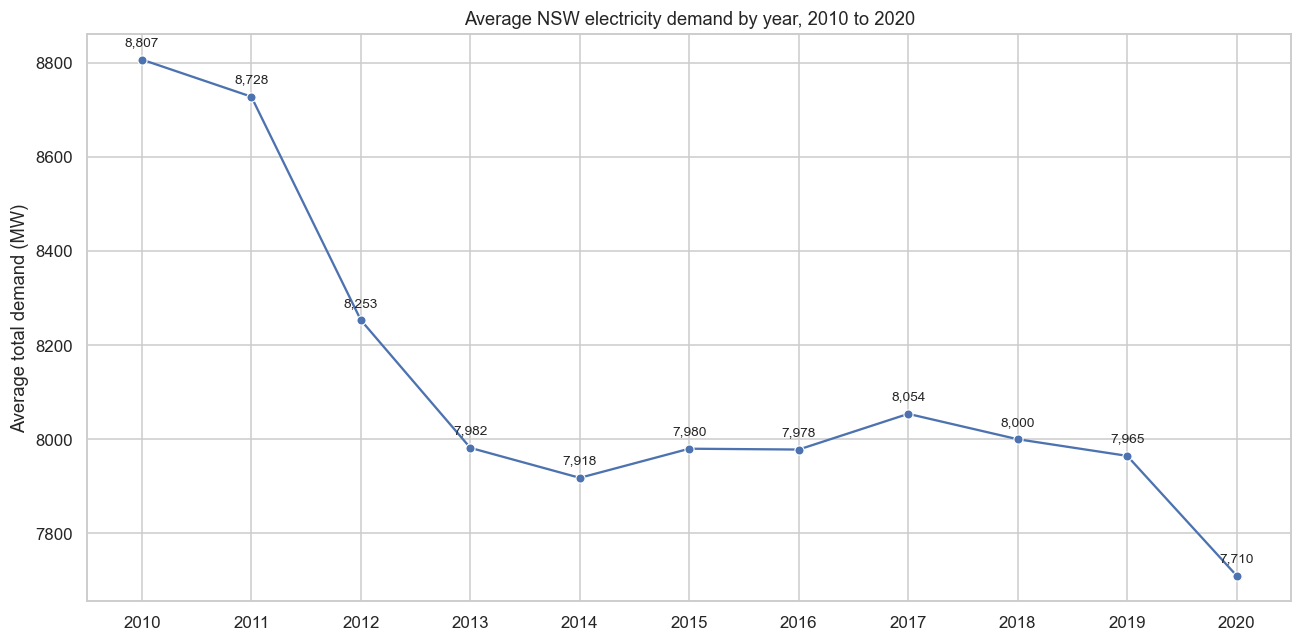

In [54]:
yearly_summary = (
    complete_years.groupby("YEAR")["TOTALDEMAND"]
    .agg(average="mean", median="median", standard_deviation="std")
)
yearly_summary.columns = [
    "Average demand (MW)", "Median demand (MW)", "Standard deviation (MW)"
]
yearly_summary["Annual change (%)"] = (
    yearly_summary["Average demand (MW)"].pct_change() * 100
)

plt.figure(figsize=(12, 6))
ax = sns.lineplot(
    x=yearly_summary.index,
    y=yearly_summary["Average demand (MW)"],
    marker="o"
)
for year, value in yearly_summary["Average demand (MW)"].items():
    ax.annotate(
        f"{value:,.0f}",
        (year, value),
        textcoords="offset points",
        xytext=(0, 9),
        ha="center",
        fontsize=9
    )

plt.title("Average NSW electricity demand by year, 2010 to 2020")
plt.xlabel("")
plt.ylabel("Average total demand (MW)")
plt.xticks(yearly_summary.index)
plt.tight_layout()
plt.show()

**Figure 2.** Average demand by complete calendar year.

In [55]:
first, last = (
    yearly_summary["Average demand (MW)"].iloc[0],
    yearly_summary["Average demand (MW)"].iloc[-1],
)
print(f"Change from 2010 to 2020: {(last / first - 1) * 100:.2f}%")
print("\nTable 12. Yearly summary, complete calendar years only.")
yearly_summary.round(2)

Change from 2010 to 2020: -12.46%

Table 12. Yearly summary, complete calendar years only.


,Average demand (MW),Median demand (MW),Standard deviation (MW),Annual change (%)
YEAR,,,,
2010,8807.19,8924.26,1373.97,NaN
2011,8728.29,8809.56,1353.71,-0.90
2012,8253.29,8318.12,1251.65,-5.44
2013,7981.59,8045.04,1190.93,-3.29
2014,7917.80,7984.69,1170.11,-0.80
2015,7979.76,7990.36,1232.71,0.78
2016,7977.98,7940.24,1257.25,-0.02
2017,8053.87,7960.74,1303.48,0.95
2018,7999.90,7946.70,1185.82,-0.67


### Finding

Figure 2 and Table 12 show an overall but uneven decline in average electricity demand. Annual average demand decreased from 8,807.19 MW in 2010 to 7,709.77 MW in 2020, representing a total reduction of 12.46%.

The largest annual decreases occurred in 2012 and 2013, when average demand fell by 5.44% and 3.29%, respectively. From 2013 to 2019, annual averages were comparatively stable, remaining between approximately 7,900 MW and 8,054 MW. A further decline of 3.20% occurred in 2020.

This pattern indicates that the long-term movement is not adequately described as a smooth, constant decline. Instead, the series contains periods of decline followed by relative stability. This has implications for forecasting because models based on a single linear trend may not adapt effectively to changes in the demand level. The causes of these changes cannot be established from demand data alone and would require additional explanatory variables and structural-break analysis.

These shifts suggest that structural changes such as policy, technology, or economic conditions may have affected demand, and that models should be tested for sensitivity to such regime changes.

## 9. Multiple seasonal decomposition

Daily average demand carries at least two cycles: a weekly one and an
annual one. A single period decomposition can only remove one of them, so
whichever cycle is left unmodelled ends up in the residual and inflates
it. MSTL fits several seasonal periods at once (Bandara, Hyndman and
Bergmeir, 2021), so both are removed and can be reported separately. Both
versions are fitted below so the difference is visible rather than
asserted.

In [58]:
from statsmodels.tsa.seasonal import STL, MSTL

half_hourly = demand.set_index("DATETIME")["TOTALDEMAND"]
intervals_per_day = half_hourly.resample("D").count()

incomplete_days = intervals_per_day[intervals_per_day != 48]

print("Days with fewer than 48 intervals:")
print(incomplete_days)

daily_demand = half_hourly.resample("D").mean()
daily_demand = daily_demand[intervals_per_day == 48].asfreq("D")

print("\nComplete days retained:", len(daily_demand))
print(
    "Range:",
    daily_demand.index.min().date(),
    "to",
    daily_demand.index.max().date()
)
print("Missing daily values:", daily_demand.isna().sum())

Days with fewer than 48 intervals:
DATETIME
2021-03-18    1
Freq: D, Name: TOTALDEMAND, dtype: int64

Complete days retained: 4094
Range: 2010-01-01 to 2021-03-17
Missing daily values: 0


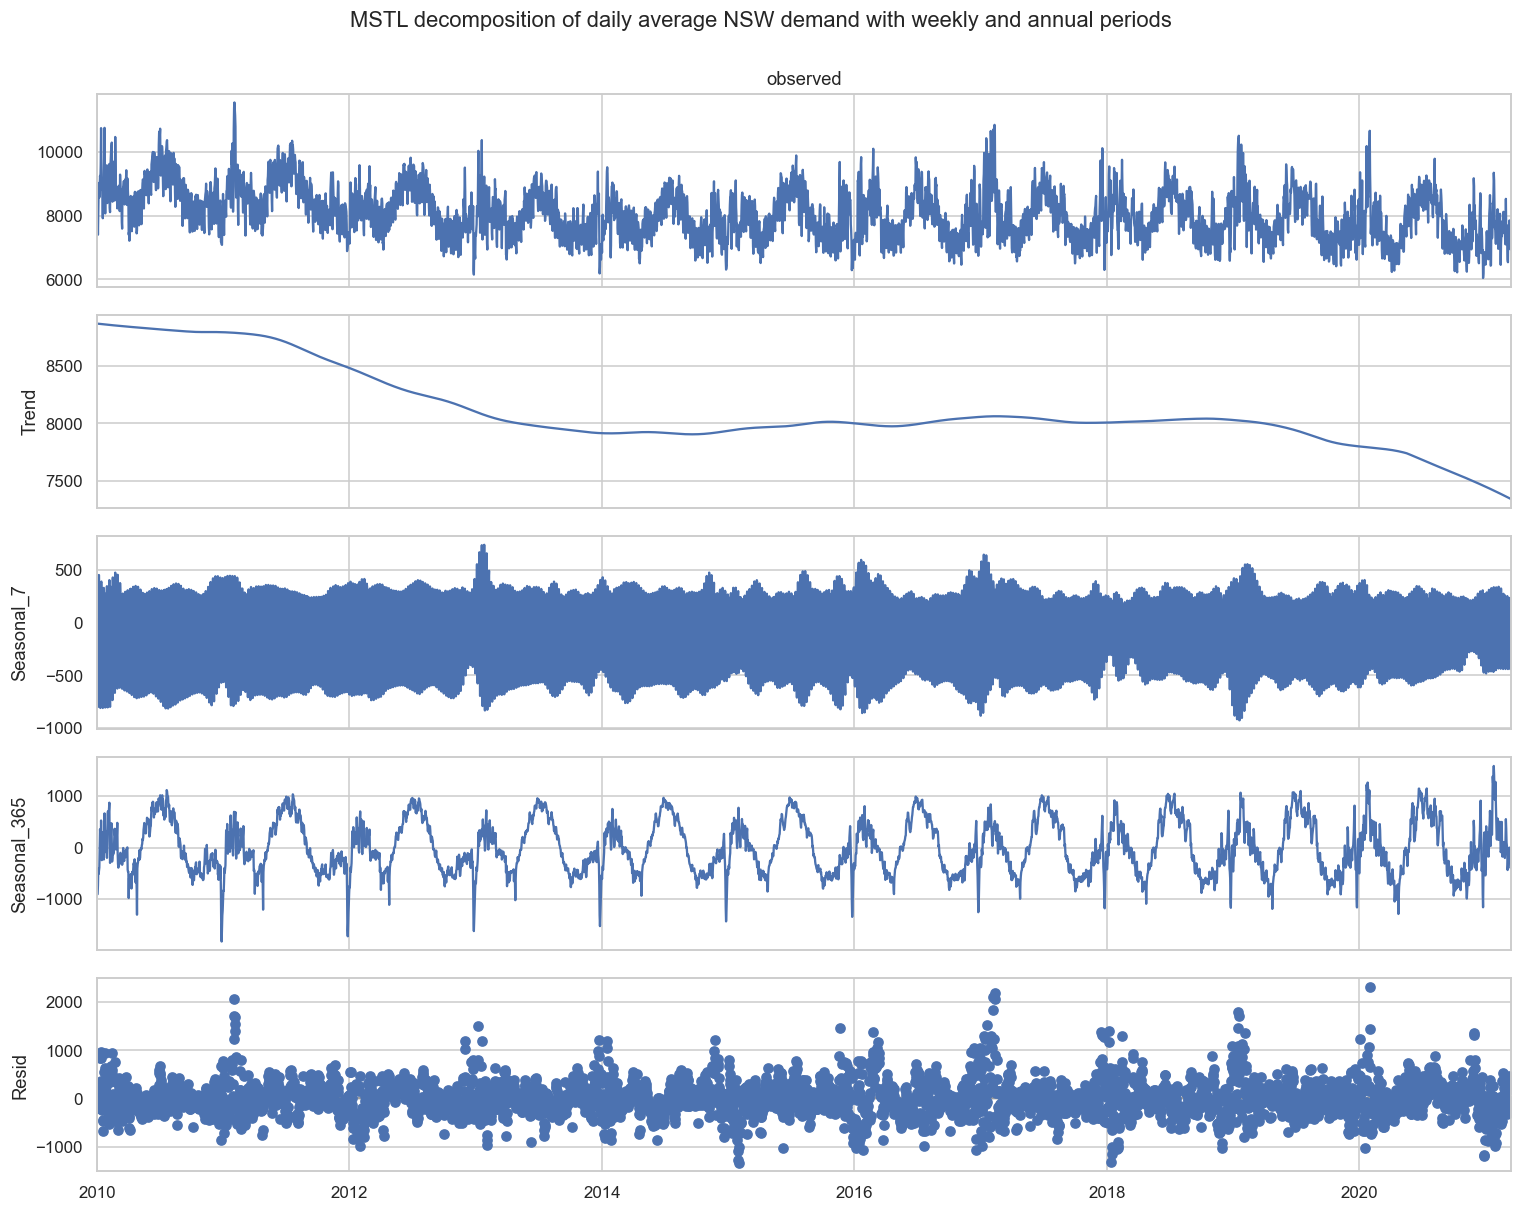

In [59]:
def seasonal_strength(component, residual):
    """Strength measure of Wang, Smith and Hyndman (2006), as set out in
    Hyndman and Athanasopoulos (2021). Bounded at zero, close to one when
    the component explains most of the variation it shares with the
    residual."""
    return max(0.0, 1 - residual.var() / (component + residual).var())


mstl_result = MSTL(daily_demand, periods=(7, 365)).fit()

trend = mstl_result.trend
weekly = mstl_result.seasonal["seasonal_7"]
annual = mstl_result.seasonal["seasonal_365"]
residual = mstl_result.resid

fig = mstl_result.plot()
fig.set_size_inches(14, 11)
fig.suptitle(
    "MSTL decomposition of daily average NSW demand with weekly and annual periods",
    y=1.00
)
plt.tight_layout()
plt.show()

**Figure 1.** MSTL decomposition of daily average demand into trend, weekly seasonality, annual seasonality and residual.

The strength of each component is calculated using the variance-based measure proposed by Wang, Smith and Hyndman (2006) and described by Hyndman and Athanasopoulos (2021). MSTL is also compared with the original single-seasonal STL method developed by Cleveland et al. (1990).

In [60]:
components = pd.DataFrame({
    "Trend": trend,
    "Weekly seasonal": weekly,
    "Annual seasonal": annual,
    "Residual": residual,
})

component_summary = components.agg(["mean", "std", "min", "max"]).T
component_summary.columns = [
    "Mean (MW)", "Std dev (MW)", "Minimum (MW)", "Maximum (MW)"
]
component_summary["Strength"] = [
    seasonal_strength(trend, residual),
    seasonal_strength(weekly, residual),
    seasonal_strength(annual, residual),
    np.nan,
]

print("Table 13. MSTL components and strength measures.")
component_summary.round(3)

Table 13. MSTL components and strength measures.


,Mean (MW),Std dev (MW),Minimum (MW),Maximum (MW),Strength
Trend,8106.554,346.525,7336.854,8871.455,0.490
Weekly seasonal,-0.121,342.930,-925.563,735.181,0.492
Annual seasonal,4.885,510.474,-1820.712,1588.225,0.673
Residual,1.832,356.113,-1332.831,2311.752,NaN


In [61]:
# Single period version, for comparison only.
stl_result = STL(daily_demand, period=365).fit()

method_comparison = pd.DataFrame({
    "STL, annual period only": [
        seasonal_strength(stl_result.seasonal, stl_result.resid),
        seasonal_strength(stl_result.trend, stl_result.resid),
        stl_result.resid.std(),
    ],
    "MSTL, weekly and annual": [
        seasonal_strength(annual, residual),
        seasonal_strength(trend, residual),
        residual.std(),
    ],
}, index=[
    "Annual seasonal strength",
    "Trend strength",
    "Residual standard deviation (MW)",
])

print("Table 14. Effect of leaving the weekly cycle in the residual.")
method_comparison.round(3)

Table 14. Effect of leaving the weekly cycle in the residual.


,"STL, annual period only","MSTL, weekly and annual"
Annual seasonal strength,0.697,0.673
Trend strength,0.427,0.490
Residual standard deviation (MW),394.499,356.113


### Finding

Table 13 reports an annual seasonal strength of 0.673, a weekly seasonal strength of 0.492 and a trend strength of 0.490. The annual component ranges from approximately −1,820.71 MW to 1,588.22 MW, while the weekly component spans approximately 1,660 MW. The estimated trend ranges from 7,336.85 MW to 8,871.46 MW, supporting the long‑term movement identified earlier after seasonal variation has been separated.

Table 14 compares MSTL with a single‑period STL decomposition. The annual‑only STL produces an annual seasonal strength of 0.697 and a trend strength of 0.427. MSTL produces a slightly lower annual strength of 0.673 but a higher trend strength of 0.490 because it models weekly and annual seasonality separately.

Most importantly, the residual standard deviation decreases from 394.50 MW under STL to 356.11 MW under MSTL, a reduction of approximately 9.7%. This indicates that explicitly modelling the weekly cycle leaves less systematic variation in the residual. MSTL is therefore more appropriate for this series than an annual‑only decomposition.

The improvement from MSTL reflects the fact that electricity demand contains a strong weekly cycle driven by commercial and industrial activity, which STL cannot remove when restricted to an annual period.

Because MSTL produces a cleaner residual, models trained on MSTL‑detrended data may achieve better short‑term accuracy, particularly during periods with strong weekly structure.

## 10. Autocorrelation and stationarity

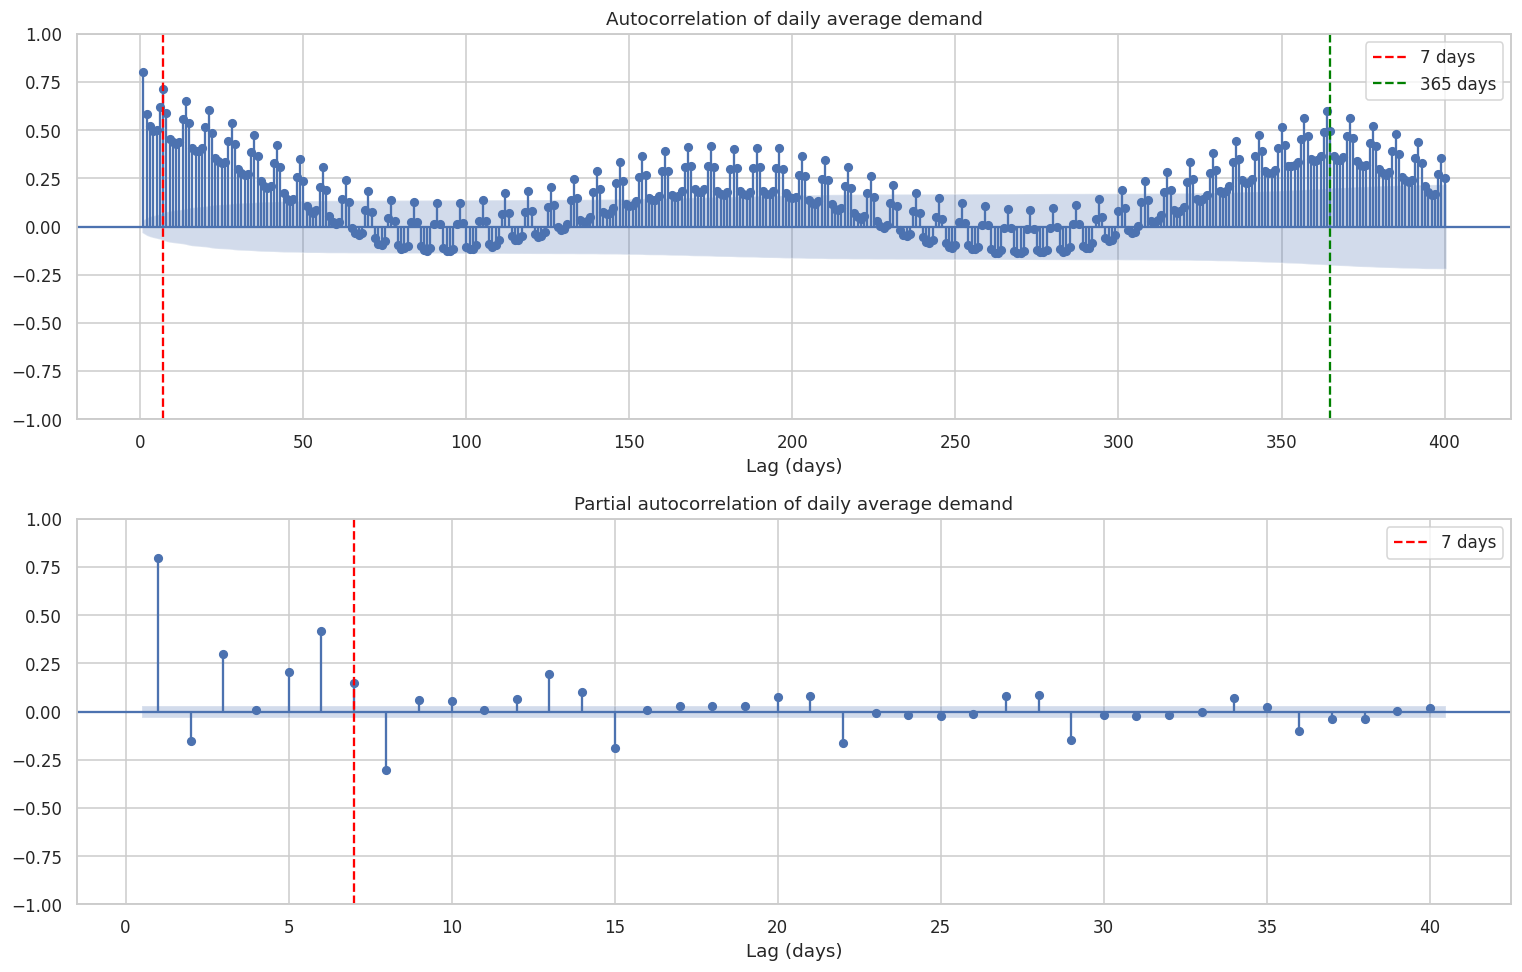

In [29]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9))

plot_acf(daily_demand, lags=400, ax=axes[0], fft=True, zero=False)
axes[0].axvline(7, color="red", linestyle="--", label="7 days")
axes[0].axvline(365, color="green", linestyle="--", label="365 days")
axes[0].set_title("Autocorrelation of daily average demand")
axes[0].set_xlabel("Lag (days)")
axes[0].legend()

plot_pacf(daily_demand, lags=40, ax=axes[1], method="ywm", zero=False)
axes[1].axvline(7, color="red", linestyle="--", label="7 days")
axes[1].set_title("Partial autocorrelation of daily average demand")
axes[1].set_xlabel("Lag (days)")
axes[1].legend()

plt.tight_layout()
plt.show()

**Figure 1.** Autocorrelation of daily average demand to a lag of 400
days, and partial autocorrelation to a lag of 40 days. Shaded bands are
the 95 per cent confidence interval.

In [30]:
lags = {"Previous day": 1, "Previous week": 7,
        "Approximately one month": 30, "Previous year": 365}

acf_table = pd.DataFrame(
    [{"Lag (days)": lag,
      "Autocorrelation": daily_demand.autocorr(lag=lag)}
     for lag in lags.values()],
    index=lags.keys()
)

print("Table 15. Autocorrelation at selected lags.")
acf_table.round(3)

Table 15. Autocorrelation at selected lags.


,Lag (days),Autocorrelation
Previous day,1,0.799
Previous week,7,0.715
Approximately one month,30,0.301
Previous year,365,0.575


Stationarity is assessed using the Augmented Dickey–Fuller test (Said & Dickey, 1984) and the KPSS test (Kwiatkowski et al., 1992). These tests use opposing null hypotheses and are therefore interpreted together.

In [31]:
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tools.sm_exceptions import InterpolationWarning
warnings.filterwarnings("ignore", category=InterpolationWarning)
def stationarity_report(series, label):
    adf_stat, adf_p = adfuller(series, autolag="AIC")[:2]
    kpss_stat, kpss_p = kpss(series, regression="c", nlags="auto")[:2]
    return {
        "Series": label,
        "ADF statistic": adf_stat,
        "ADF p value": adf_p,
        "KPSS statistic": kpss_stat,
        "KPSS p value": kpss_p,
    }


tests = pd.DataFrame([
    stationarity_report(daily_demand, "Daily demand, levels"),
    stationarity_report(daily_demand.diff().dropna(),
                        "Daily demand, first difference"),
]).set_index("Series")

print("ADF null hypothesis: a unit root is present, so the series is not "
      "stationary.")
print("KPSS null hypothesis: the series is stationary around a constant "
      "level.")
print("\nTable 16. Stationarity tests.")
tests.round(4)

ADF null hypothesis: a unit root is present, so the series is not stationary.
KPSS null hypothesis: the series is stationary around a constant level.

Table 16. Stationarity tests.


,ADF statistic,ADF p value,KPSS statistic,KPSS p value
Series,,,,
"Daily demand, levels",-5.7448,0.0,2.5950,0.01
"Daily demand, first difference",-14.4853,0.0,0.0125,0.10


### Finding

Figure 1 and Table 15 demonstrate strong temporal dependence in daily electricity demand. Autocorrelation is 0.799 at a one‑day lag and 0.715 at a seven‑day lag, confirming substantial short‑term persistence and a recurring weekly pattern. Autocorrelation decreases to 0.301 at approximately one month but rises to 0.575 at 365 days, providing further evidence of annual seasonality. These autocorrelation patterns are consistent with the MSTL decomposition in Section 9, which also identified strong weekly and annual seasonal components.

The partial autocorrelation is strongest at the first few lags, with an additional visible contribution at lag seven. This indicates that recent daily observations and observations from the same day of the previous week may provide useful forecasting information. However, the raw autocorrelation values should not be interpreted as the independent predictive contribution of each lag because different lagged observations contain overlapping information.

Table 16 provides mixed evidence regarding stationarity in the level series. The ADF test rejects its null hypothesis of a unit root, with a statistic of −5.745 and a p‑value below 0.001. In contrast, the KPSS test rejects its null hypothesis of level stationarity, with a statistic of 2.595 and a reported p‑value of 0.01 or lower. The KPSS rejection is expected because deterministic seasonality and long‑term mean shifts violate the assumption of stationarity around a fixed level. This combination is consistent with a series containing deterministic seasonal patterns and changes in its mean, rather than providing straightforward evidence of a single stochastic unit root.

After first differencing, the ADF test continues to reject a unit root, while the KPSS test does not reject stationarity. This indicates that first differencing substantially stabilises the series. Nevertheless, the final treatment should be selected through model diagnostics: an ARIMA‑family model may use differencing or explicit trend and seasonal terms, while models without a stationarity assumption can use suitable time and lag features.

Lagged features must be constructed using only information available at the forecast origin to prevent data leakage. For short‑term half‑hourly forecasting, useful candidates include recent half‑hourly observations, the same time on the previous day and the same time in the previous week. These correspond to half‑hourly lags such as 1, 24, 48 and 336 intervals. The strong daily and weekly dependence identified above supports evaluating these features within a chronological training and testing design.

## 11. Temperature and electricity demand

Temperature is examined as a potential explanatory variable for short-term electricity demand. The Bankstown temperature series is used as the available weather measure for NSW demand. Because electricity use may increase during both unusually hot and unusually cold conditions, the relationship may be nonlinear rather than a simple straight-line association.

The analysis first examines the overall relationship between temperature and demand and then considers whether it changes across seasons and times of day.

Because temperature affects both heating and cooling behaviour, its contribution to demand varies across seasons and times of day.

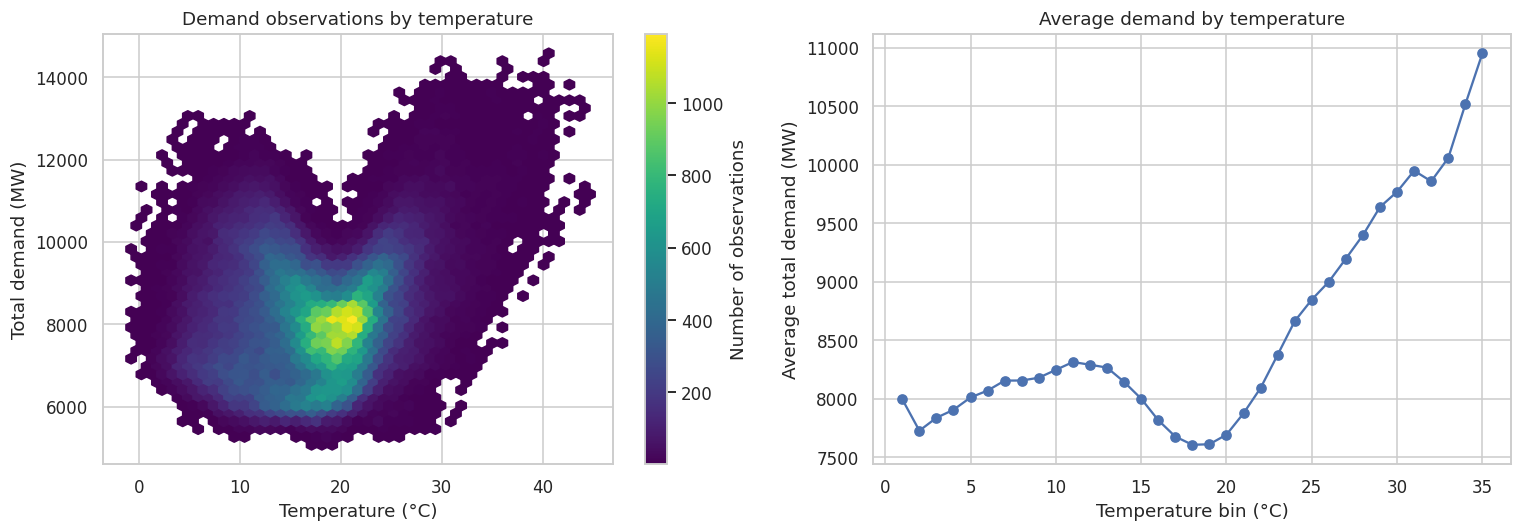

Pearson correlation: 0.149
Spearman correlation: 0.119
Temperature range: -1.3°C to 44.7°C


In [32]:
temp = demand[["TEMPERATURE", "TOTALDEMAND"]].dropna()
temp_avg = (
    temp.assign(TEMP_BIN=np.floor(temp["TEMPERATURE"]))
    .groupby("TEMP_BIN")["TOTALDEMAND"]
    .agg(["mean", "count"])
    .query("count >= 100")["mean"]
)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

plot = ax[0].hexbin(
    temp["TEMPERATURE"], temp["TOTALDEMAND"],
    gridsize=45, mincnt=1, cmap="viridis"
)
ax[0].set(
    title="Demand observations by temperature",
    xlabel="Temperature (°C)",
    ylabel="Total demand (MW)"
)
fig.colorbar(plot, ax=ax[0], label="Number of observations")

ax[1].plot(temp_avg.index, temp_avg.values, marker="o")
ax[1].set(
    title="Average demand by temperature",
    xlabel="Temperature bin (°C)",
    ylabel="Average total demand (MW)"
)

plt.tight_layout()
plt.show()

print("Pearson correlation:",
      round(temp["TEMPERATURE"].corr(temp["TOTALDEMAND"]), 3))
print("Spearman correlation:",
      round(temp["TEMPERATURE"].corr(temp["TOTALDEMAND"], method="spearman"), 3))
print(
    f"Temperature range: {temp['TEMPERATURE'].min():.1f}°C "
    f"to {temp['TEMPERATURE'].max():.1f}°C"
)

**Figure 1.** Relationship between Bankstown temperature and NSW electricity demand. The left panel shows the concentration of half-hourly observations, while the right panel shows average demand within one-degree temperature bins containing at least 100 observations.

### Finding

Figure 1 shows that the relationship between temperature and electricity demand is nonlinear. Average demand is lowest at approximately 18–20°C and increases substantially as temperature rises above 20°C. Demand also tends to be higher under colder conditions than under mild conditions, although the hot-weather increase is considerably stronger. This V‑shaped pattern reflects increased heating demand at low temperatures and increased cooling demand at high temperatures.

The Pearson correlation is 0.149 and the Spearman correlation is 0.119. These relatively weak overall correlations do not indicate that temperature is unimportant. Instead, a single correlation coefficient inadequately represents the curved relationship visible in the graph.

This pooled relationship may also be influenced by season and time of day. Temperature should therefore be considered together with temporal features, and nonlinear temperature terms or tree-based models may represent its forecasting contribution better than a single linear term.

Because temperature strongly influences peak demand, incorporating temperature into short‑term forecasting models can improve accuracy during extreme weather conditions.

### 11.1 Temperature relationship by season and time of day

The pooled temperature relationship combines observations recorded during different seasons and times of day. This can hide important differences because both the normal temperature range and the normal demand level change over time.

To examine this interaction, demand is compared across temperature ranges separately for each season and for four periods of the day: overnight, morning, afternoon and evening.

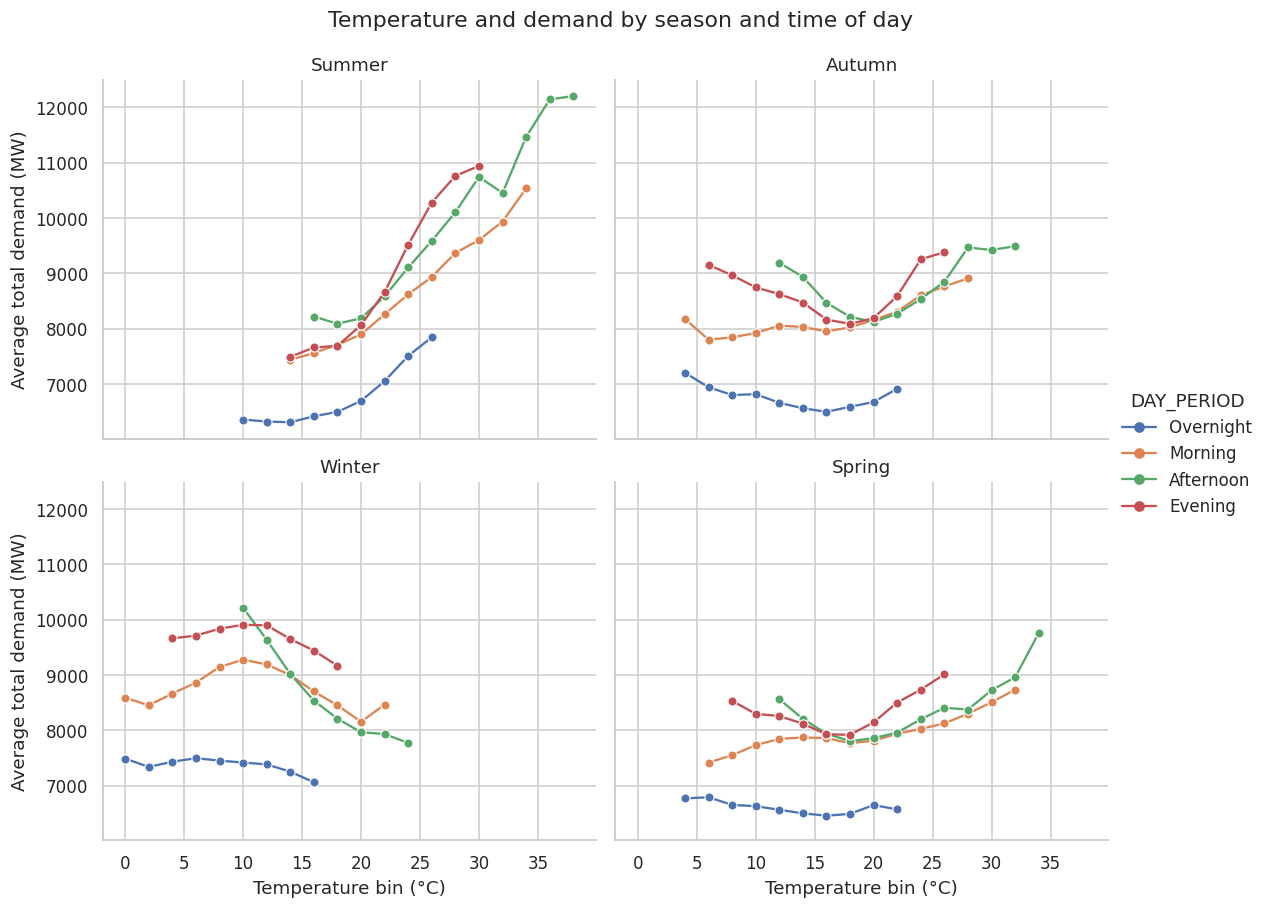

In [33]:
temp_multi = demand.assign(
    TEMP_BIN=np.floor(demand["TEMPERATURE"] / 2) * 2,
    DAY_PERIOD=pd.cut(
        demand["HOUR"],
        bins=[0, 6, 12, 18, 24],
        labels=["Overnight", "Morning", "Afternoon", "Evening"],
        right=False
    )
)

temp_profile = (
    temp_multi
    .groupby(
        ["SEASON", "DAY_PERIOD", "TEMP_BIN"],
        observed=True
    )["TOTALDEMAND"]
    .agg(AVERAGE_DEMAND="mean", OBSERVATIONS="count")
    .query("OBSERVATIONS >= 50")
    .reset_index()
)

grid = sns.relplot(
    data=temp_profile,
    x="TEMP_BIN",
    y="AVERAGE_DEMAND",
    hue="DAY_PERIOD",
    col="SEASON",
    col_order=season_order,
    col_wrap=2,
    kind="line",
    marker="o",
    height=4,
    aspect=1.3
)

grid.set_axis_labels("Temperature bin (°C)", "Average total demand (MW)")
grid.set_titles("{col_name}")
grid.figure.suptitle(
    "Temperature and demand by season and time of day",
    y=1.03
)

plt.show()

**Figure 2.** Average NSW electricity demand across two-degree temperature ranges, separated by season and time of day. Only combinations containing at least 50 observations are displayed.

Temperature affects electricity demand differently across seasons and times of day. In summer, demand increases sharply at higher temperatures, particularly during the afternoon and evening when cooling loads are strongest. Winter shows the opposite pattern: demand increases at lower temperatures, especially during the morning and evening heating periods. Spring and autumn display flatter profiles because temperatures are generally milder and less extreme.

The time‑of‑day effect is also important. Afternoon demand increases rapidly at high temperatures in summer, while overnight demand is comparatively insensitive to temperature in all seasons. These results indicate that temperature interacts with both season and time of day, and that pooled temperature–demand relationships can obscure important differences.

Forecasting models should therefore include temperature together with seasonal and hourly features, and nonlinear temperature terms or tree‑based models may better represent these interactions than a single linear temperature coefficient.

### Finding

Figure 2 shows that the temperature–demand relationship changes substantially across seasons and times of day. In summer, demand increases sharply above approximately 20°C, particularly during the afternoon and evening. The strongest hot-weather response occurs during summer afternoons, when average demand exceeds 12,000 MW at the highest reliably represented temperatures.

Winter shows a different pattern. Demand is generally higher under colder conditions, especially during the morning, afternoon and evening, and decreases as temperatures become milder. Autumn and spring show more moderate curved relationships, with demand generally lowest around mild temperatures.

Overnight demand remains lower than demand during the other periods in every season and is less sensitive to temperature. These results show that temperature should not be represented as an isolated linear predictor. Forecasting models should allow temperature to interact with season and time of day, either through interaction features, nonlinear transformations or tree-based methods.

## 12. Public holidays and school-term periods

Calendar conditions may affect short-term electricity demand because work, school and household activity patterns change during public holidays and school breaks. The available indicators are therefore examined to determine whether average demand differs between public holidays and other days, and between school-term and non-school-term periods.

These comparisons are descriptive rather than causal because public holidays and school breaks are not distributed evenly across seasons or days of the week. The analysis therefore considers day type and season when interpreting the differences.

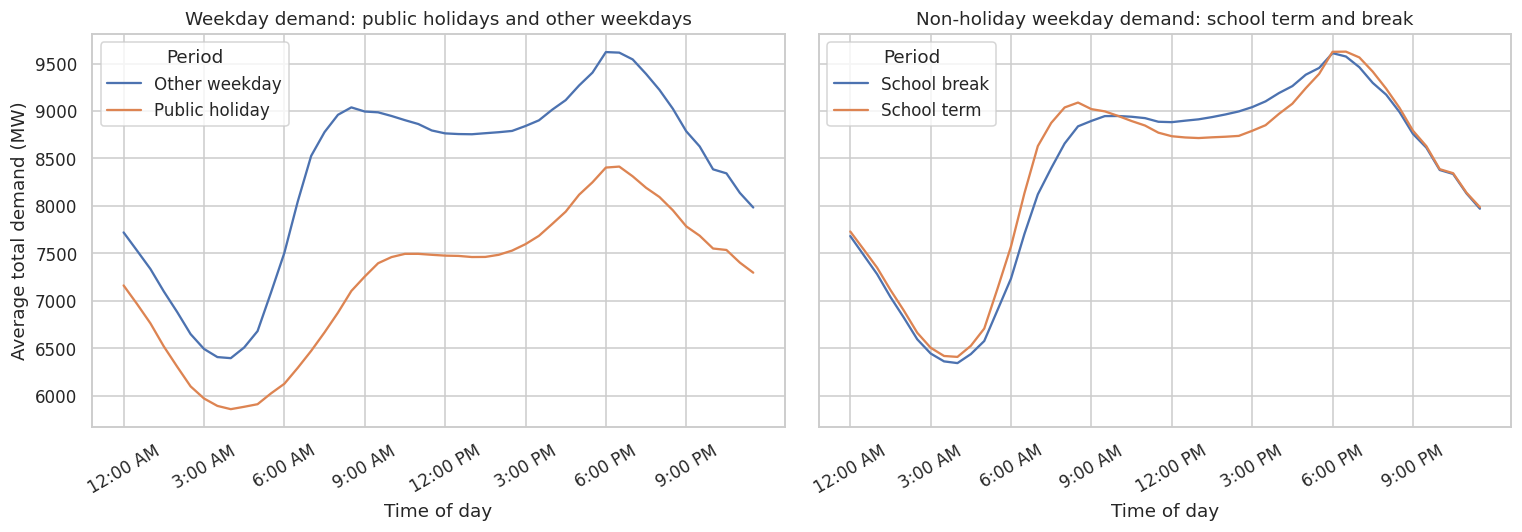

In [34]:
weekdays = demand[~demand["IS_WEEKEND"]].copy()

holiday_profile = (
    weekdays.groupby(["is_public_holiday", "HOUR"])["TOTALDEMAND"]
    .mean()
    .reset_index()
)
holiday_profile["Period"] = np.where(
    holiday_profile["is_public_holiday"],
    "Public holiday",
    "Other weekday"
)

school_profile = (
    weekdays[~weekdays["is_public_holiday"]]
    .groupby(["is_school_term", "HOUR"])["TOTALDEMAND"]
    .mean()
    .reset_index()
)
school_profile["Period"] = np.where(
    school_profile["is_school_term"],
    "School term",
    "School break"
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

sns.lineplot(
    data=holiday_profile, x="HOUR", y="TOTALDEMAND",
    hue="Period", ax=axes[0]
)
axes[0].set_title("Weekday demand: public holidays and other weekdays")

sns.lineplot(
    data=school_profile, x="HOUR", y="TOTALDEMAND",
    hue="Period", ax=axes[1]
)
axes[1].set_title("Non-holiday weekday demand: school term and break")

for ax in axes:
    ticks = range(0, 24, 3)
    ax.set_xticks(ticks)
    ax.set_xticklabels([format_time(h) for h in ticks], rotation=30)
    ax.set_xlabel("Time of day")
    ax.set_ylabel("Average total demand (MW)")

plt.tight_layout()
plt.show()

In [35]:
other_weekdays = weekdays[~weekdays["is_public_holiday"]]
public_holidays = weekdays[weekdays["is_public_holiday"]]

school_term = other_weekdays[other_weekdays["is_school_term"]]
school_break = other_weekdays[~other_weekdays["is_school_term"]]

def calendar_summary(data):
    profile = data.groupby("HOUR")["TOTALDEMAND"].mean()
    return {
        "Days": data["DATE"].nunique(),
        "Average demand (MW)": data["TOTALDEMAND"].mean(),
        "Peak demand (MW)": profile.max(),
        "Peak time": format_time(profile.idxmax())
    }

calendar_table = pd.DataFrame({
    "Other weekday": calendar_summary(other_weekdays),
    "Public holiday": calendar_summary(public_holidays),
    "School term": calendar_summary(school_term),
    "School break": calendar_summary(school_break)
}).T

print("Table 17. Calendar-period demand summary.")
display(
    calendar_table.style.format({
        "Days": "{:.0f}",
        "Average demand (MW)": "{:,.2f}",
        "Peak demand (MW)": "{:,.2f}",
        "Peak time": "{}"
    })
)

Table 17. Calendar-period demand summary.


,Days,Average demand (MW),Peak demand (MW),Peak time
Other weekday,2826,"8,353.72","9,620.89",6:00 PM
Public holiday,99,"7,217.06","8,414.60",6:30 PM
School term,2252,"8,360.02","9,625.47",6:30 PM
School break,574,"8,329.02","9,609.68",6:00 PM


In [36]:
holiday_season = weekdays.pivot_table(
    index="SEASON",
    columns="is_public_holiday",
    values="TOTALDEMAND",
    aggfunc="mean"
).rename(columns={
    False: "Other weekday mean (MW)",
    True: "Public holiday mean (MW)"
})

holiday_season["Holiday reduction (%)"] = (
    1 - holiday_season["Public holiday mean (MW)"]
    / holiday_season["Other weekday mean (MW)"]
) * 100

school_season = other_weekdays.pivot_table(
    index="SEASON",
    columns="is_school_term",
    values="TOTALDEMAND",
    aggfunc="mean"
).rename(columns={
    False: "School break mean (MW)",
    True: "School term mean (MW)"
})

school_season["Term difference (%)"] = (
    school_season["School term mean (MW)"]
    / school_season["School break mean (MW)"] - 1
) * 100

season_calendar = (
    holiday_season.join(school_season)
    .reindex(season_order)
)

print("Table 18. Calendar effects within each season.")
display(season_calendar.style.format("{:,.2f}"))

Table 18. Calendar effects within each season.


,Other weekday mean (MW),Public holiday mean (MW),Holiday reduction (%),School break mean (MW),School term mean (MW),Term difference (%)
SEASON,,,,,,
Summer,"8,423.94","7,220.68",14.28,"8,400.98","8,437.96",0.44
Autumn,"8,164.31","7,008.88",14.15,"7,790.88","8,222.47",5.54
Winter,"8,959.04","8,103.02",9.55,"9,168.82","8,920.70",-2.71
Spring,"7,861.01","6,902.64",12.19,"7,736.18","7,882.16",1.89


**Figure 14.** Average half-hourly weekday demand profiles for public holidays and other weekdays, and for school-term and school-break periods after excluding public holidays.

### Finding

Figure 14 and Table 17 show a substantial public-holiday effect. Average weekday demand is 8,353.72 MW on other weekdays but falls to 7,217.06 MW on public holidays, a reduction of approximately 1,136.66 MW or 13.6%. The average peak also decreases from 9,620.89 MW to 8,414.60 MW and occurs 30 minutes later.

Table 18 shows that this reduction occurs in every season. It ranges from 9.55% in winter to 14.28% in summer, indicating that public-holiday status contains useful forecasting information beyond the ordinary weekday/weekend distinction. However, the result should be interpreted cautiously because only 99 public-holiday weekdays are available, compared with 2,826 other weekdays.

The overall school-term effect is much smaller. Average demand is 8,360.02 MW during school terms and 8,329.02 MW during school breaks, a difference of approximately 31 MW. The daily profiles and peak levels are also very similar. However, the within-season difference varies from −2.71% in winter to 5.54% in autumn. This suggests that school-term status may interact with season, but its standalone relationship with demand is weaker and less consistent than the public-holiday effect.

Public-holiday status should therefore be retained as a forecasting feature. School-term status can also be evaluated, but its usefulness should be confirmed through out-of-sample model performance.

## 13. Existing forecast performance

The dataset contains three existing demand forecasts: the closest available forecast, a 12-hour-prior forecast and a day-prior forecast. Their predictions are compared with actual demand to establish reference performance before new forecasting models are developed.

Performance is assessed using mean absolute error (MAE), root mean squared error (RMSE), mean absolute percentage error (MAPE) and mean error (bias). MAE measures the typical error magnitude, RMSE gives greater weight to large errors, MAPE expresses error relative to demand, and bias indicates whether forecasts tend to overpredict or underpredict.

Because the issue horizon represented by `forecast_closest` is not explicitly stated, it is treated as a descriptive reference. The clearly labelled 12-hour-prior and day-prior forecasts provide the more interpretable short-term benchmarks.

In [37]:
forecast_columns = {
    "Closest forecast": "forecast_closest",
    "12-hour-prior forecast": "forecast_12hr_prior",
    "Day-prior forecast": "forecast_dayprior"
}

forecast_results = []

for name, column in forecast_columns.items():
    valid = demand[["TOTALDEMAND", column]].dropna()
    actual = valid["TOTALDEMAND"]
    predicted = valid[column]
    error = actual - predicted

    forecast_results.append({
        "Forecast": name,
        "Observations": len(valid),
        "MAE (MW)": mean_absolute_error(actual, predicted),
        "RMSE (MW)": np.sqrt(mean_squared_error(actual, predicted)),
        "MAPE (%)": mean_absolute_percentage_error(actual, predicted) * 100,
        "Mean error (MW)": error.mean()
    })

forecast_table = (
    pd.DataFrame(forecast_results)
    .set_index("Forecast")
    .sort_values("MAE (MW)")
)

print("Table 19. Overall performance of the existing forecasts.")
print("Positive mean error indicates underprediction; negative indicates overprediction.")

display(
    forecast_table.style.format({
        "Observations": "{:,.0f}",
        "MAE (MW)": "{:,.2f}",
        "RMSE (MW)": "{:,.2f}",
        "MAPE (%)": "{:.2f}",
        "Mean error (MW)": "{:,.2f}"
    })
)

Table 19. Overall performance of the existing forecasts.
Positive mean error indicates underprediction; negative indicates overprediction.


,Observations,MAE (MW),RMSE (MW),MAPE (%),Mean error (MW)
Forecast,,,,,
Closest forecast,"196,513",62.33,85.87,0.76,-9.11
12-hour-prior forecast,"196,513",169.08,234.87,2.05,8.20
Day-prior forecast,"196,513",177.83,247.03,2.16,9.60


### 13.1 Forecast accuracy across operating conditions

Overall accuracy measures can hide periods when forecasting is more difficult. The 12-hour-prior and day-prior forecasts are therefore evaluated separately across seasons, day types and demand levels.

Demand levels are used only to evaluate performance after the actual demand is observed. They must not be included as model predictors because they are calculated directly from the target variable.

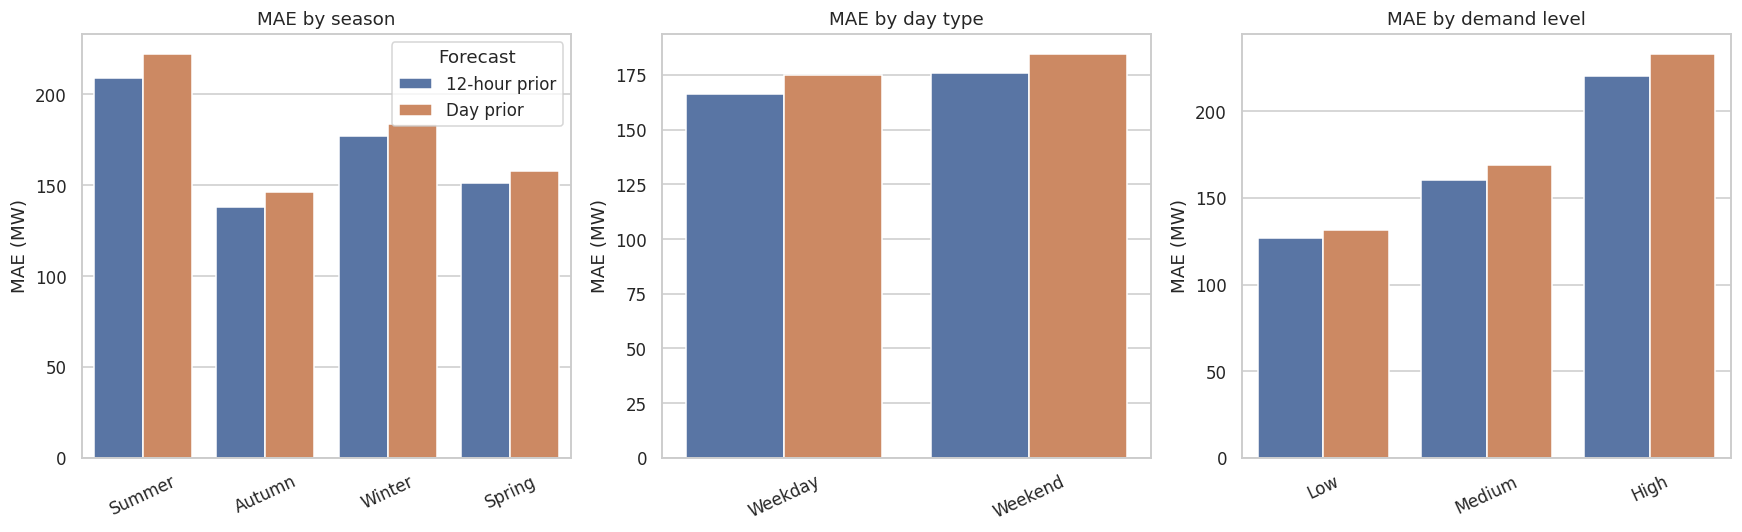

Table 20. Forecast MAE across operating conditions.


In [38]:
benchmarks = {
    "12-hour prior": "forecast_12hr_prior",
    "Day prior": "forecast_dayprior"
}

groups = {
    "Season": ("SEASON", season_order),
    "Day type": ("DAY_TYPE", ["Weekday", "Weekend"]),
    "Demand level": ("DEMAND_LEVEL", ["Low", "Medium", "High"])
}

rows = []

for forecast_name, column in benchmarks.items():
    absolute_error = (demand["TOTALDEMAND"] - demand[column]).abs()

    for factor, (variable, order) in groups.items():
        values = (
            demand.assign(ABSOLUTE_ERROR=absolute_error)
            .groupby(variable, observed=True)["ABSOLUTE_ERROR"]
            .mean()
            .reindex(order)
        )

        for group, mae in values.items():
            rows.append([factor, group, forecast_name, mae])

segment_mae = pd.DataFrame(
    rows, columns=["Factor", "Group", "Forecast", "MAE (MW)"]
)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (factor, (_, order)) in zip(axes, groups.items()):
    sns.barplot(
        data=segment_mae[segment_mae["Factor"] == factor],
        x="Group", y="MAE (MW)", hue="Forecast",
        order=order, ax=ax
    )
    ax.set_title(f"MAE by {factor.lower()}")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=25)

axes[1].legend_.remove()
axes[2].legend_.remove()

plt.tight_layout()
plt.show()

segment_table = segment_mae.pivot(
    index=["Factor", "Group"],
    columns="Forecast",
    values="MAE (MW)"
)

print("Table 20. Forecast MAE across operating conditions.")
display(segment_table.style.format("{:,.2f}"))

**Figure 15.** Mean absolute error of the 12-hour-prior and day-prior forecasts across seasons, day types and observed demand levels.

### Finding

Figure 15 and Table 20 show that the 12-hour-prior forecast has a lower MAE than the day-prior forecast in every examined group. This indicates that the additional information available closer to the demand period consistently improves forecasting accuracy.

Both forecasts perform worst during summer. The 12-hour-prior MAE reaches 208.80 MW in summer, compared with 137.86 MW in autumn. The day-prior forecast shows the same pattern, with MAE increasing from 146.18 MW in autumn to 222.24 MW in summer. This may reflect the stronger and more variable temperature response observed during hot summer conditions.

Forecasting is also slightly more difficult during weekends. The 12-hour-prior MAE increases from 166.26 MW on weekdays to 176.13 MW on weekends, while the day-prior MAE increases from 175.09 MW to 184.66 MW.

The largest differences occur across demand levels. For the 12-hour-prior forecast, MAE increases from 126.66 MW under Low demand to 220.49 MW under High demand. The day-prior MAE similarly increases from 131.71 MW to 233.03 MW. This shows that pooled accuracy measures can hide weaker performance during operationally important high-demand periods.

Demand levels are used here only for post-forecast evaluation and must not be included as predictor variables. Future models should be assessed separately across these conditions as well as through overall accuracy measures.

### 13.2 Forecast accuracy across temperature conditions

Forecast performance is also examined across temperature conditions because the earlier analysis showed a strong nonlinear demand response during hot weather. Temperature is divided into four descriptive groups: Cold (below 10°C), Mild (10°C to below 20°C), Warm (20°C to below 30°C) and Hot (30°C or above).

These groups use observed temperature only to evaluate when the existing forecasts perform well or poorly. Observed future temperature must not be used as a model predictor unless it would genuinely be available at the forecast origin; operational models would normally require an appropriate weather forecast.

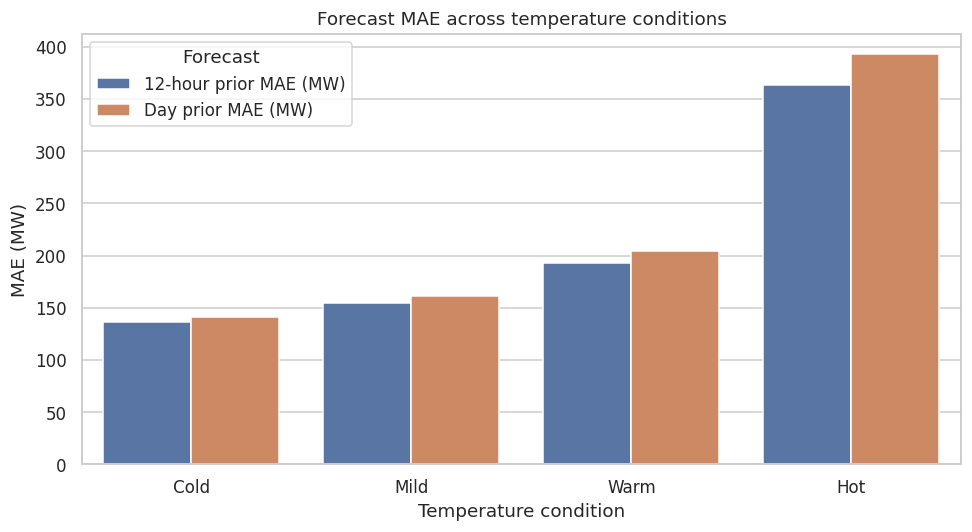

Table 21. Forecast accuracy across temperature conditions.


,Observations,12-hour prior MAE (MW),Day prior MAE (MW)
Temperature_group,,,
Cold,"21,948",136.65,141.44
Mild,"104,343",154.36,161.43
Warm,"66,948",193.13,204.80
Hot,"3,274",363.76,392.88


In [39]:
temperature_order = ["Cold", "Mild", "Warm", "Hot"]

temperature_eval = demand.assign(
    Temperature_group=pd.cut(
        demand["TEMPERATURE"],
        bins=[-np.inf, 10, 20, 30, np.inf],
        labels=temperature_order,
        right=False
    ),
    AE_12=(demand["TOTALDEMAND"] - demand["forecast_12hr_prior"]).abs(),
    AE_day=(demand["TOTALDEMAND"] - demand["forecast_dayprior"]).abs()
)

temperature_accuracy = (
    temperature_eval
    .groupby("Temperature_group", observed=True)
    .agg(
        Observations=("TOTALDEMAND", "size"),
        **{
            "12-hour prior MAE (MW)": ("AE_12", "mean"),
            "Day prior MAE (MW)": ("AE_day", "mean")
        }
    )
    .reindex(temperature_order)
)

plot_data = (
    temperature_accuracy
    .drop(columns="Observations")
    .reset_index()
    .melt(
        id_vars="Temperature_group",
        var_name="Forecast",
        value_name="MAE (MW)"
    )
)

plt.figure(figsize=(9, 5))
sns.barplot(
    data=plot_data,
    x="Temperature_group",
    y="MAE (MW)",
    hue="Forecast",
    order=temperature_order
)
plt.title("Forecast MAE across temperature conditions")
plt.xlabel("Temperature condition")
plt.ylabel("MAE (MW)")
plt.tight_layout()
plt.show()

print("Table 21. Forecast accuracy across temperature conditions.")
display(
    temperature_accuracy.style.format({
        "Observations": "{:,.0f}",
        "12-hour prior MAE (MW)": "{:,.2f}",
        "Day prior MAE (MW)": "{:,.2f}"
    })
)

**Figure 16.** Mean absolute error of the 12-hour-prior and day-prior forecasts across observed temperature conditions.

### Finding

Figure 16 and Table 21 show that forecast accuracy decreases substantially as temperature rises. For the 12-hour-prior forecast, MAE increases from 136.65 MW under Cold conditions to 193.13 MW under Warm conditions and 363.76 MW under Hot conditions. The day-prior forecast follows the same pattern, with MAE increasing from 141.44 MW under Cold conditions to 392.88 MW under Hot conditions.

The 12-hour-prior forecast performs better in every temperature group. Its advantage is largest during Hot conditions, where its MAE is approximately 29.12 MW lower than the day-prior forecast. This suggests that information obtained closer to the forecast period becomes especially valuable during rapidly changing or extreme weather conditions.

Only 3,274 observations fall within the Hot category, compared with 104,343 Mild observations. Nevertheless, these periods are operationally important because they are associated with both high electricity demand and the largest forecast errors.

These results support including nonlinear temperature effects and interactions with season and time of day in future models. Model evaluation should also report hot-weather performance separately rather than relying only on pooled accuracy.

## 14. Conclusion

This exploratory analysis examined 196,513 half-hourly NSW electricity-demand observations from January 2010 to March 2021. The data contain no missing values or duplicated timestamps. The final calendar date contains only one observation because the series ends at midnight, so it was excluded only from the daily decomposition. No demand observations were removed as outliers because most extreme values formed sustained high-demand events that are important for forecasting.

Electricity demand shows strong temporal structure. Average demand reaches its daily minimum near 4:00 a.m. and peaks around 6:30 p.m. Weekday demand is approximately 9.29% higher than weekend demand, while seasonal profiles differ in both magnitude and shape. Winter records the highest seasonal peak, and monthly demand is highest in July and lowest in October. Annual average demand declined by 12.46% between 2010 and 2020, although this decline was uneven.

MSTL decomposition confirms meaningful weekly and annual seasonality, while the autocorrelation analysis shows strong dependence at one-day, seven-day and annual lags. These findings support using recent half-hourly demand together with same-time previous-day and previous-week lags. Time of day, day of week, season and their interactions should also be represented in the forecasting models.

Temperature has a nonlinear and time-dependent relationship with demand. Demand is generally lowest under mild conditions and rises sharply during hot weather, particularly on summer afternoons and evenings. Winter demand is comparatively higher during colder conditions. Temperature should therefore be represented through nonlinear terms or models capable of learning interactions with season and time of day.

Public holidays have a substantial effect, reducing average weekday demand by approximately 13.6%. This reduction appears in every season. School-term and school-break averages differ by only about 31 MW overall, although the relationship varies across seasons. Public-holiday status should be retained as a forecasting feature, while the contribution of school-term status should be confirmed through out-of-sample testing.

Among the clearly defined existing benchmarks, the 12-hour-prior forecast performs better than the day-prior forecast, with overall MAEs of 169.08 MW and 177.83 MW, respectively. Forecast errors increase during summer, weekends, high-demand periods and especially hot weather. Under Hot conditions, MAE reaches 363.76 MW for the 12-hour-prior forecast and 392.88 MW for the day-prior forecast.

Future short-term forecasting models should therefore combine temporal, lagged-demand, nonlinear temperature and public-holiday information. Evaluation should use chronological training and testing, prevent future-information leakage and report performance separately across seasons, day types, demand levels and temperature conditions. The 12-hour-prior and day-prior forecasts provide clear operational benchmarks for comparing the new models.

## References
AEMO, 2023. Market Data NEMWeb and Data Model Report Guide. Australian Energy Market Operator, Melbourne.

Bandara, K., Hyndman, R.J. and Bergmeir, C., 2021. MSTL: A seasonal trend decomposition algorithm for time series with multiple seasonal patterns. arXiv preprint arXiv:2107.13462.

Cleveland, R.B., Cleveland, W.S., McRae, J.E. and Terpenning, I., 1990. STL: A seasonal trend decomposition procedure based on loess. Journal of Official Statistics, 6(1), pp.3-73.

Hyndman, R.J. and Athanasopoulos, G., 2021. Forecasting: Principles and Practice. 3rd ed. OTexts, Melbourne. Available at https://otexts.com/fpp3/

Kwiatkowski, D., Phillips, P.C.B., Schmidt, P. and Shin, Y., 1992. Testing the null hypothesis of stationarity against the alternative of a unit root. Journal of Econometrics, 54(1 to 3), pp.159 to 178.

Said, S.E. and Dickey, D.A., 1984. Testing for unit roots in autoregressive moving average models of unknown order. Biometrika, 71(3), pp.599 to 607.


Wang, X., Smith, K. and Hyndman, R., 2006. Characteristic based clustering for time series data. Data Mining and Knowledge Discovery, 13(3), pp.335 to 364.
